In [307]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [385]:
df_raw = pd.read_excel('../mRNA_seq/mRNA_seq_AS_Control_LncRNA_identificados.xlsx')
#Eliminamos todas las variables que Norm ya que prefiero hacer nuestra propia normalizacion
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains('Norm')]
#trasponemos para que cada fila sea un paciente y cada columna sea una variable , incluimos el simbolo de hgnc como nombre de columnas  y eliminamos variables que son string
df_raw = df_raw.set_index('hgnc_symbol').drop(['description','gene_biotype','chromosome_name'],axis = 1).T


In [386]:
info_Adicional = pd.read_csv('../mRNA_seq/pacientesInfoAdicional.csv',sep = ';')
info_Adicional['Sexo'] = info_Adicional['Sexo'].str.lower()
info_Adicional['Sexo'] = pd.get_dummies(info_Adicional['Sexo']).astype(int)['hombre']
info_Adicional['Grupo_Tratamiento'] = pd.get_dummies(info_Adicional['Condición']).astype(int)['estenosis aórtica']
info_Adicional = info_Adicional.drop('Condición', axis = 1)

### Lecturas bajas

Consideramos variables con lectuas bajas aquellas que tengan una frecuencia mayor del 50% con lecturas de menor de un threshold:

Text(0.5, 1.0, 'Suma de las lecturas de cada variable ordenadas')

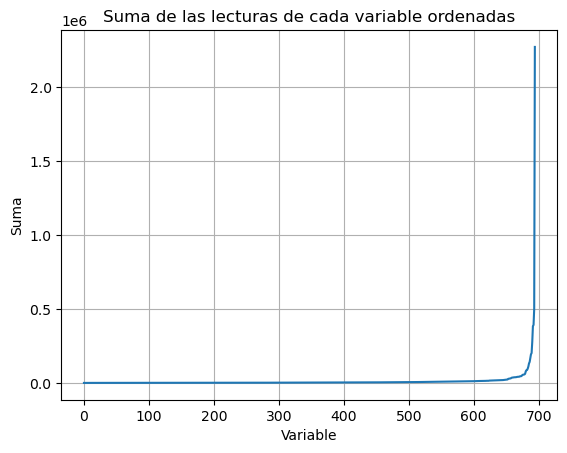

In [387]:

# Primer gráfico: Suma
#plt.xticks(np.arange(600, 700, 10))
plt.plot(df_raw.sum().sort_values().to_list())
#plt.xlim(600, 700)
plt.grid(True)
plt.xlabel('Variable')
plt.ylabel('Suma')
plt.title('Suma de las lecturas de cada variable ordenadas')

In [103]:
x_objetivo = 600

suma_lecturas = df_raw.sum().sort_values()
suma_lecturas_list = suma_lecturas.to_list()
indice_mas_cercano = np.abs(suma_lecturas.reset_index(drop = True).index - x_objetivo).argmin()
valor_y_correspondiente = suma_lecturas.iloc[indice_mas_cercano]

print(f"El valor de y correspondiente a x={x_objetivo} es: {valor_y_correspondiente}")


El valor de y correspondiente a x=600 es: 12331


In [104]:
suma_min = valor_y_correspondiente
filtered = df_raw.sum().sort_values()
cols_interes = filtered[filtered>suma_min].index.to_list()
df_raw_lecAltas1 = df_raw[cols_interes]
len(df_raw_lecAltas1.columns)

94

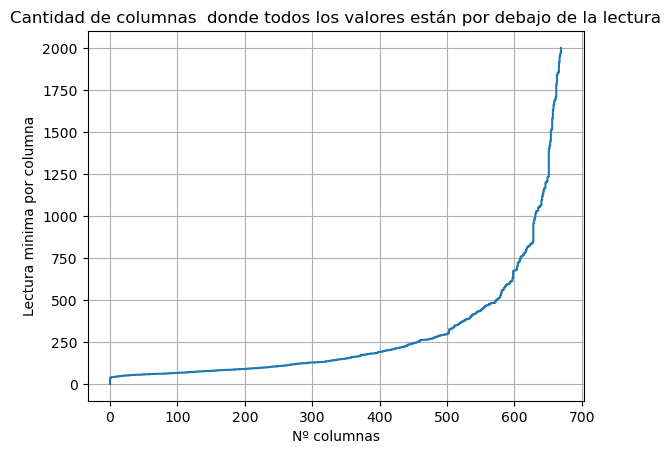

In [109]:
lista_mediaCercACero = []
lecturas_mins = np.arange(0,2000,0.1)
for lectMin in lecturas_mins:
    #for frec in np.arange(0,1,0.1):
    mediaCercACero = (df_raw < lectMin).sum() #vemos cuántos valores de cada columna están por debajo de ese umbral
    mediaCercACero = mediaCercACero[mediaCercACero == len(df_raw)] #Filtramos las columnas en donde todos los valores están por debajo de ese umbral
    lista_mediaCercACero.append(len(mediaCercACero))
#plt.xticks(np.arange(0,20,1))
plt.plot(lista_mediaCercACero, lecturas_mins)
plt.xlabel('Nº columnas')
plt.ylabel('Lectura minima por columna')
plt.title('Cantidad de columnas  donde todos los valores están por debajo de la lectura') 
plt.grid(True)
plt.show()




In [ ]:
ncol = 600
indice_mas_cercano = np.abs(np.array(lista_mediaCercACero) - ncol).argmin()
lectura_correspondiente = lecturas_mins[indice_mas_cercano] 
print(f"El valor de lectura correspondiente a y={ncol} es aproximadamente: {lectura_correspondiente}")

El valor de lectura correspondiente a x=600 es aproximadamente: 673.1


In [8]:
lecturaMinElegida = lectura_correspondiente
#Filtrar aquellas celdas que están por debajo de la lectura minima y sumar para cada variable qué registras están por debajo
colAEliminar = (df_raw < lecturaMinElegida).sum() 
#Aquellas columnas en las que todos sus registros están por debajo de la lectura mínima las eliminamos
colAEliminar = colAEliminar[colAEliminar == len(df_raw)].index.to_list() 
df_raw_lecAltas2 = df_raw.drop(colAEliminar,axis = 1)
len(df_raw_lecAltas2.columns)

95

In [9]:
colsLectAlta = list(set(df_raw_lecAltas1.columns.to_list() + df_raw_lecAltas2.columns.to_list()))
len(colsLectAlta)
print(len(df_raw.columns),'->',len(colsLectAlta))

695 -> 106


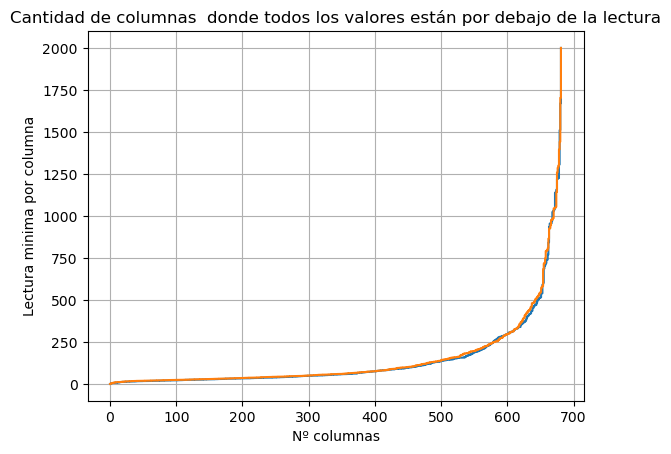

In [224]:
df1_ct = df_raw.copy().reset_index()
df1_ct['Grupo'] = np.where(df1_ct['index'].str.contains('A'), 'Tratamiento', 
              np.where(df1_ct['index'].str.contains('C'), 'Control', 'Otro'))
df1_ct = df1_ct.set_index('index')
df1_trnto = df1_ct[df1_ct['Grupo'] == 'Tratamiento'].drop('Grupo', axis = 1)
df1_ctrl = df1_ct[df1_ct['Grupo'] == 'Control'].drop('Grupo', axis = 1)
df1_ct = df1_ct.drop('Grupo', axis = 1)

lista_CercACero_trntro = []
lista_CercACero_ctrl = []
lecturas_mins = np.arange(0,2000,0.1)
umbral = 0.3
for lectMin in lecturas_mins:
    #for frec in np.arange(0,1,0.1):
    porcTrnto = (df1_trnto < lectMin).sum() /len(df1_trnto)
    porcTrnto = porcTrnto[porcTrnto > umbral] #qué cantidad de columnas tienen un mínimo del 50% por encima de un valor
    ncolstrnto = len(porcTrnto[porcTrnto != 0])
    porcCtrl = (df1_ctrl < lectMin).sum()/len(df1_ctrl)
    porcCtrl = porcCtrl[porcCtrl > umbral] 
    ncolsctrl = len(porcCtrl[porcCtrl != 0])
    lista_CercACero_ctrl.append(ncolsctrl)
    lista_CercACero_trntro.append(ncolstrnto)

#plt.xticks(np.arange(0,20,1))
plt.plot(lista_CercACero_ctrl, lecturas_mins)
plt.plot(lista_CercACero_trntro, lecturas_mins)
plt.xlabel('Nº columnas')
plt.ylabel('Lectura minima por columna')
plt.title('Cantidad de columnas  donde todos los valores están por debajo de la lectura') 
plt.grid(True)
plt.show()

In [227]:
ncol = 600
indice_mas_cercano_ctrl = np.abs(np.array(lista_CercACero_ctrl) - ncol).argmin()
indice_mas_cercano_trnto = np.abs(np.array(lista_CercACero_trntro) - ncol).argmin()
lectura_correspondiente_ctrl = lecturas_mins[indice_mas_cercano_ctrl] 
lectura_correspondiente_trnto  = lecturas_mins[indice_mas_cercano_trnto] 
print(f"El valor de lectura correspondiente a y={ncol} es aproximadamente: {lectura_correspondiente_ctrl} en control y {lectura_correspondiente_trnto} en tratamiento")

El valor de lectura correspondiente a y=600 es aproximadamente: 295.1 en control y 295.1 en tratamiento


In [ ]:
lecturaMinElegida = min(lectura_correspondiente_ctrl,lectura_correspondiente_trnto ) 
lecturaMinElegida = lectura_correspondiente
#Filtrar aquellas celdas que están por debajo de la lectura minima y sumar para cada variable qué registras están por debajo
colAEliminar = (df_raw < lecturaMinElegida).sum() 
#Aquellas columnas en las que todos sus registros están por debajo de la lectura mínima las eliminamos
colAEliminar = colAEliminar[colAEliminar == len(df_raw)].index.to_list() 
df_raw_lecAltas2 = df_raw.drop(colAEliminar,axis = 1)
(len(df_raw_lecAltas2.columns))

95

In [229]:
colsLectAlta = list(set(df_raw_lecAltas1.columns.to_list() + df_raw_lecAltas2.columns.to_list()))
len(colsLectAlta)
print(len(df_raw.columns),'->',len(colsLectAlta))

695 -> 106


### Variaciones bajas

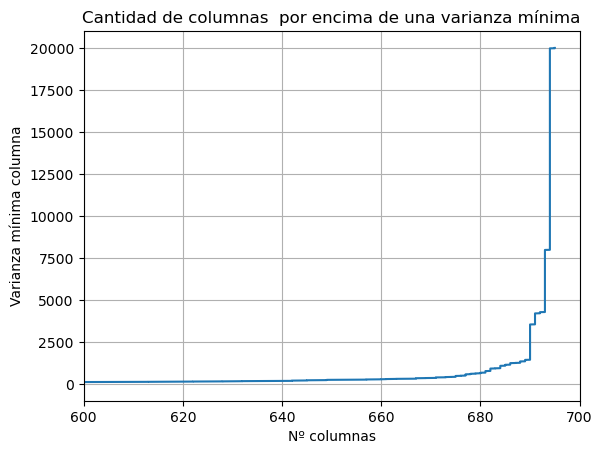

In [10]:
lista_vars = []
vars_mins = range(0,20000)
df_vars = df_raw.std()
for varMin in vars_mins:
    nVarsStd = len(df_vars[df_vars<varMin])
    lista_vars.append(nVarsStd)
#plt.xticks(np.arange(0,20,1))
plt.plot(lista_vars, vars_mins)
plt.xlim(600, 700)
plt.xlabel('Nº columnas')
plt.ylabel('Varianza mínima columna')
plt.title('Cantidad de columnas  por encima de una varianza mínima') 
plt.grid(True)
plt.show()

In [11]:
lista_vars_array = np.array(lista_vars)
vars_mins_array = np.array(vars_mins)
x_objetivo = 660
indice_mas_cercano = np.abs(lista_vars_array - x_objetivo).argmin()
varianza_minima_correspondiente = vars_mins_array[indice_mas_cercano]

print(f"La varianza mínima correspondiente a x={x_objetivo} columnas es: {varianza_minima_correspondiente}")

La varianza mínima correspondiente a x=660 columnas es: 268


In [12]:
colsVarAlta = df_vars[df_vars>varianza_minima_correspondiente].index.to_list()
print(len(df_raw.columns),'->',len(colsVarAlta))


695 -> 35


### Re-Normalización con TMM con nuevo data frame

In [13]:
colsSeleccion = list(set(colsLectAlta + colsVarAlta))
df_raw_new = df_raw[colsSeleccion]
len(colsSeleccion)

106

In [14]:
df_raw_new.to_csv('df_raw_A_Normalizar.csv',index = False)

In [351]:
df_norm_TMM = pd.read_csv('cpm_tmm.csv',index_col = 0)

In [352]:
df_norm_TMM.index = df_raw_new.index

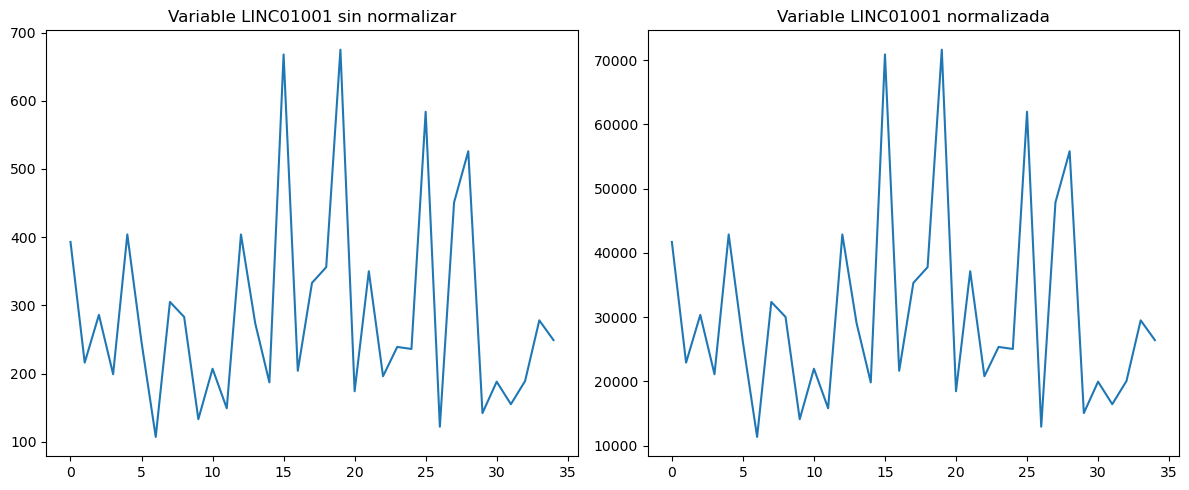

In [353]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

axes[0].plot(df_raw_new['LINC01001'].reset_index(drop=True))
axes[0].set_title('Variable LINC01001 sin normalizar')
axes[1].plot(df_norm_TMM['LINC01001'].reset_index(drop=True))
axes[1].set_title('Variable LINC01001 normalizada')

plt.tight_layout()  
plt.show()

Text(0.5, 1.0, 'Suma de las lecturas normalizadas')

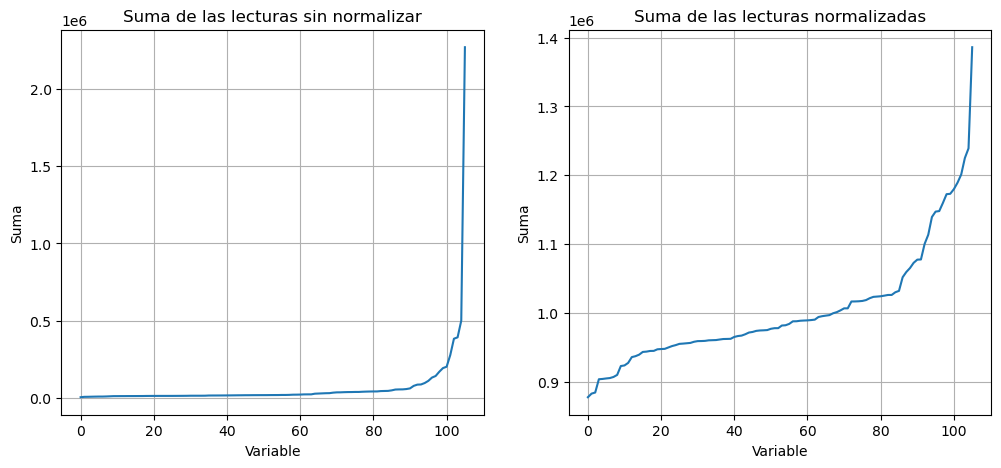

In [354]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
axes[0].plot(df_raw_new.sum().sort_values().to_list())

axes[0].grid(True)
axes[0].set_xlabel('Variable')
axes[0].set_ylabel('Suma')
axes[0].set_title('Suma de las lecturas sin normalizar')

axes[1].plot(df_norm_TMM.sum().sort_values().to_list())

axes[1].grid(True)
axes[1].set_xlabel('Variable')
axes[1].set_ylabel('Suma')
axes[1].set_title('Suma de las lecturas normalizadas')



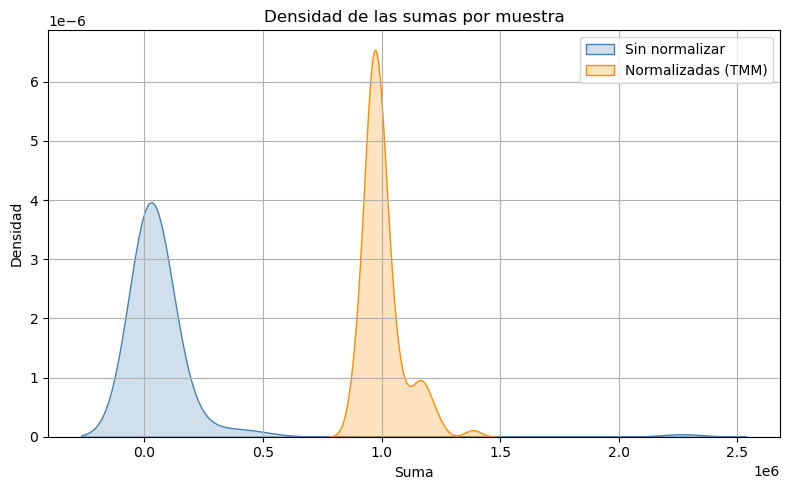

In [355]:
import seaborn as sns

plt.figure(figsize=(8, 5))

# Densidad de las lecturas sin normalizar
sns.kdeplot(df_raw_new.sum(), fill=True, label='Sin normalizar', color='steelblue')

# Densidad de las lecturas normalizadas
sns.kdeplot(df_norm_TMM.sum(), fill=True, label='Normalizadas (TMM)', color='darkorange')

plt.grid(True)
plt.xlabel('Suma')
plt.ylabel('Densidad')
plt.title('Densidad de las sumas por muestra')
plt.legend()
plt.tight_layout()
plt.show()

### Tests

Se procede a hacer un test para cada variable para determinar si existen diferencias significativas entre el grupo de Tratamiento y Control. Esto nos permitirá saber si cada variable es estadíticamente diferente o no. Las que no son diferentes podemos procederlas a eliminarlas ya que el objetivo de este análisis es determinar las diferencias entre ambos grupos

In [356]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, anderson_ksamp
from statsmodels.stats.multitest import multipletests

In [357]:
df_norm_seleccion = df_norm_TMM

In [358]:
####Dividmos el data set en dos: Uno de tratamiento y otro de control

df1_ct = df_norm_seleccion.copy().reset_index()
df1_ct['Grupo'] = np.where(df1_ct['index'].str.contains('A'), 'Tratamiento', 
              np.where(df1_ct['index'].str.contains('C'), 'Control', 'Otro'))
df1_ct = df1_ct.set_index('index')
df1_trnto = df1_ct[df1_ct['Grupo'] == 'Tratamiento'].drop('Grupo', axis = 1)
df1_ctrl = df1_ct[df1_ct['Grupo'] == 'Control'].drop('Grupo', axis = 1)
df1_ct = df1_ct.drop('Grupo', axis = 1)

In [359]:
variables = df1_ct.columns  
variablesIncluir = []
variablesExcluir = []
p_values = []
tests = []  # Para almacenar qué test se usó en cada variable

for var in variables:
    # Prueba de normalidad en ambos grupos
    p_value_trnto = shapiro(df1_trnto[var]).pvalue
    p_value_ctrl = shapiro(df1_ctrl[var]).pvalue
    # Primero comprobamos si los dos grupos siguen una distribución normal o no usando el test Shapiro-Wilk (para muestras pequeñas)
    
    if p_value_trnto > 0.05 and p_value_ctrl > 0.05:   # Si es normal, usamos t-student
        #Los dos p_values son normales → Usamos T_student
        stat, p_value = ttest_ind(df1_trnto[var], df1_ctrl[var], equal_var=False)  # Si el p-valor es menor que 0.05, diferencias significativas, Hay diferencias significativas entre los dos grupos
        test_name = 't-test'
    else:
        # Al menos un grupo no es normal → Usamos Mann-Whitney U
        stat, p_value = mannwhitneyu(df1_trnto[var], df1_ctrl[var], alternative='two-sided')
        test_name = 'Mann-Whitney'

    tests.append(test_name)
    p_values.append(p_value)  # Guardamos el p-valor obtenido

# Como se hacen muchas pruebas de manera reiterada, aplicamos la corrección FDR de Benjamini-Hochberg para evitar una acumulación de falsos positivos
reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

# Clasificar variables según la corrección FDR
variablesIncluir = [var for var, r in zip(variables, reject) if r]
variablesExcluir = [var for var, r in zip(variables, reject) if not r]

# Guardar los resultados en un DataFrame
df_resultados = pd.DataFrame({
    'Variable': variables,
    'Test aplicado': tests,
    'p-valor original': p_values,
    'p-valor ajustado (FDR)': p_adjusted,
    'Rechazar H0 (FDR)': reject #Esto es si rechazamos la hipótesis nula de que no haya diferencias signitficativas, si es true, las hay, si es false, no las hay
})

In [360]:
print(len(variables),'→',len(variablesIncluir))

106 → 7


### Correlaciones

#### Clustermaps

In [361]:
import seaborn as sns

In [388]:
df1 = df_norm_TMM[variablesIncluir]

c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


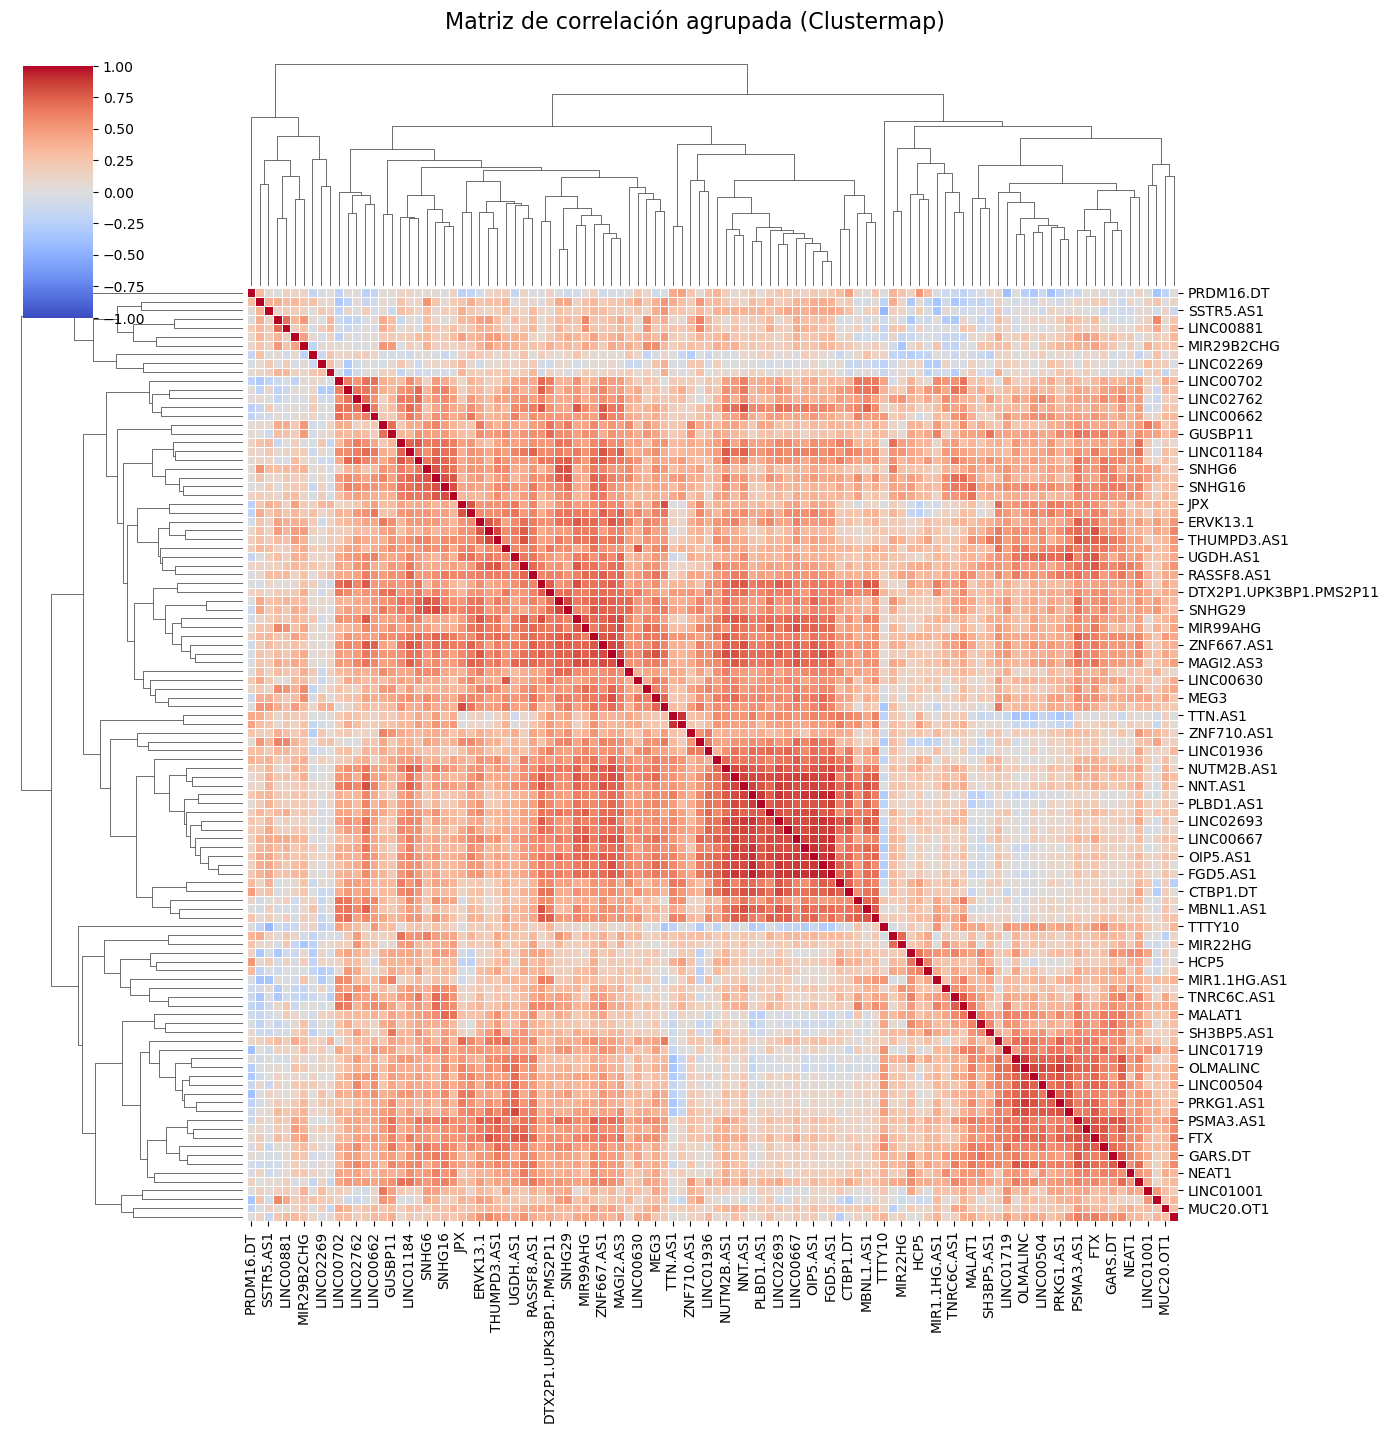

In [363]:
corr = df_norm_TMM.corr(method='spearman')
cluster = sns.clustermap(corr,
                         cmap='coolwarm',
                         vmin=-1, vmax=1,
                         figsize=(14, 14),
                         linewidths=0.5,
                         annot=False,
                         cbar_kws={"shrink": 0.7})
cluster.fig.suptitle('Matriz de correlación agrupada (Clustermap)', y=1.02, fontsize=16)
cluster.fig.savefig("../graphics/clustermap_correlacionTotal_noCod.png", bbox_inches='tight', dpi=300)
plt.show()


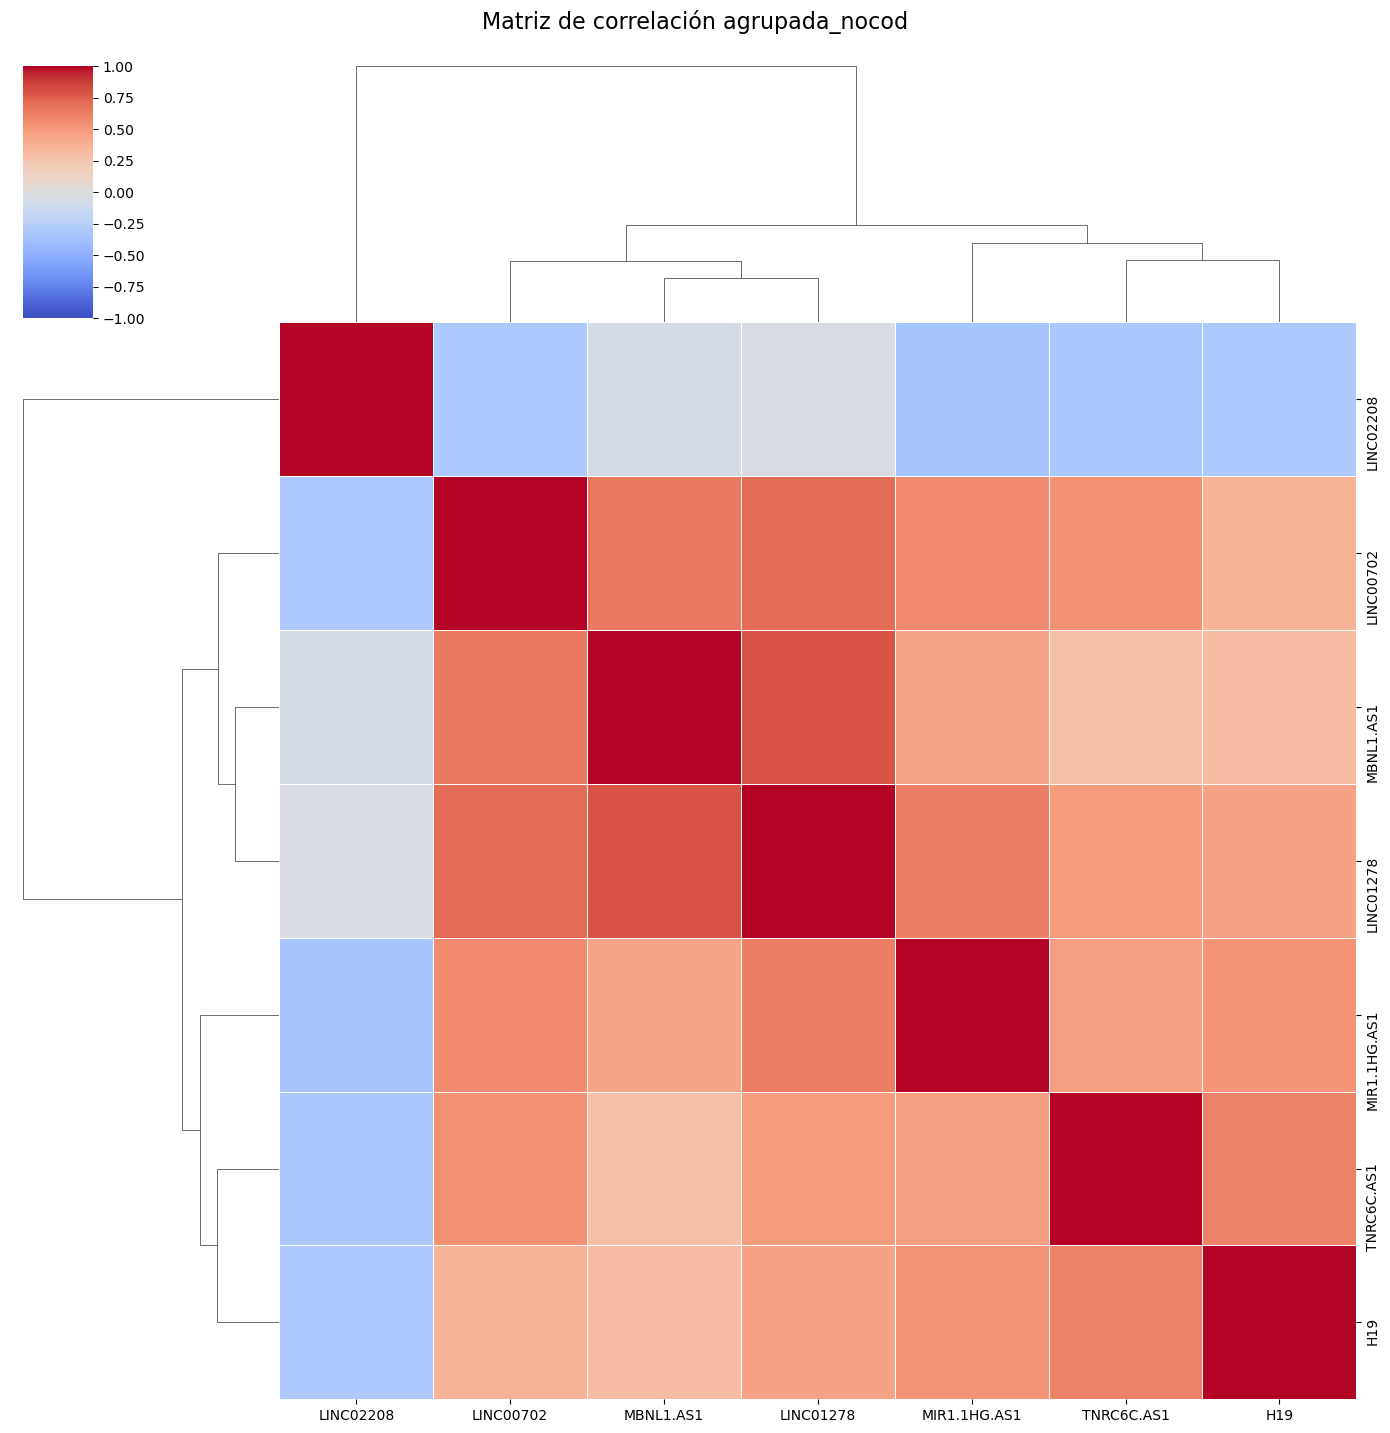

In [364]:
corr = df1.corr(method='spearman')
cluster = sns.clustermap(corr,
                         cmap='coolwarm',
                         vmin=-1, vmax=1,
                         figsize=(14, 14),
                         linewidths=0.5,
                         annot=False,
                         cbar_kws={"shrink": 0.7})
cluster.fig.suptitle('Matriz de correlación agrupada_nocod', y=1.02, fontsize=16)
cluster.fig.savefig("../graphics/clustermap_correlacion.png", bbox_inches='tight', dpi=300)
plt.show()

info mutua + correlacion en una misma matriz endograma

c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was 

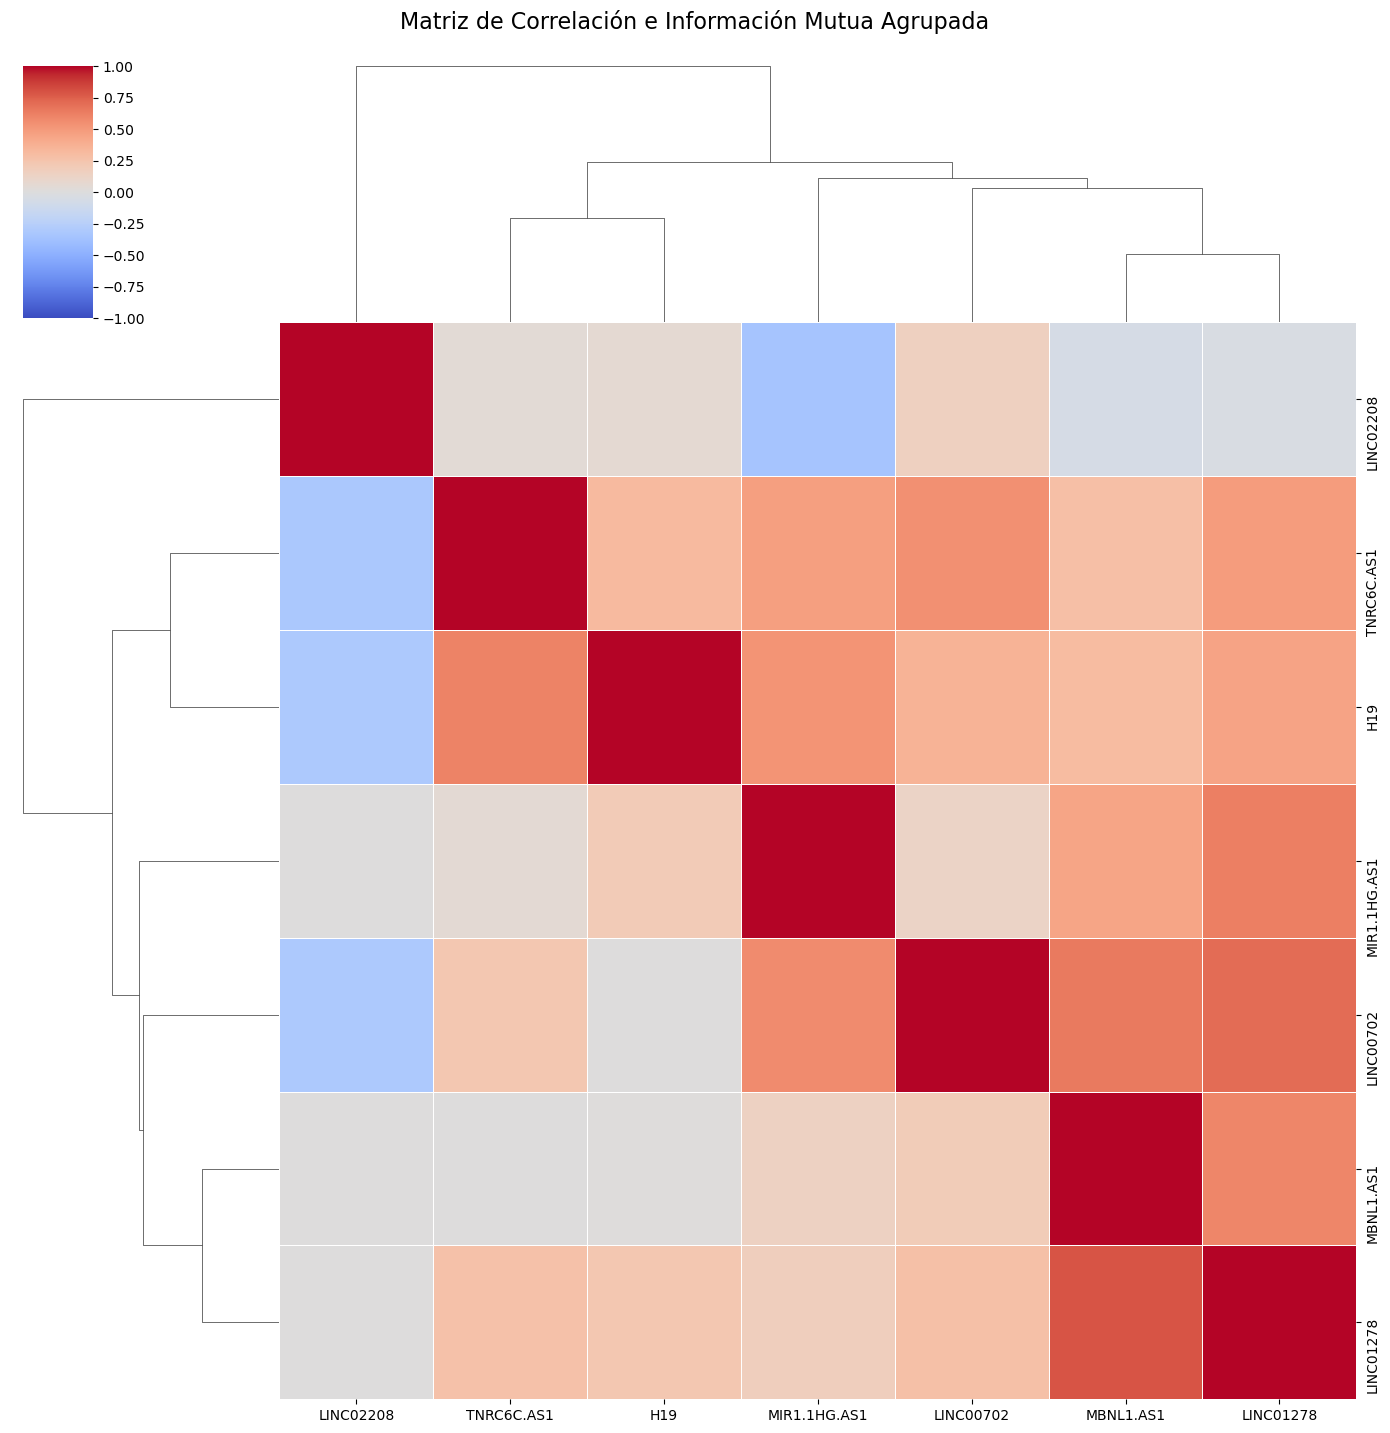

In [349]:
from sklearn.feature_selection import mutual_info_regression

corr = df1.corr(method='spearman')  
mi_matrix = np.zeros_like(corr) 

for i in range(len(df1.columns)):
    for j in range(i+1, len(df1.columns)):
        mi = mutual_info_regression(df1[[df1.columns[i]]], df1[[df1.columns[j]]])[0]
        mi_matrix[i, j] = mi
        mi_matrix[j, i] = mi
combined_matrix = np.copy(corr)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # Máscara para el lado superior de la diagonal
combined_matrix[mask] = mi_matrix[mask]

cluster = sns.clustermap(combined_matrix,
                         cmap='coolwarm',
                         vmin=-1, vmax=1,
                         figsize=(14, 14),
                         linewidths=0.5,
                         annot=False,
                         cbar_kws={"shrink": 0.7},
                         xticklabels=df1.columns,
                         yticklabels=df1.columns) 
cluster.fig.suptitle('Matriz de Correlación e Información Mutua Agrupada', y=1.02, fontsize=16)
cluster.fig.savefig("../graphics/clustermap_correlacion_informacion_mutua.png", bbox_inches='tight', dpi=300)

plt.show()

#### Distribucición variables boxplot

In [322]:
df1a = df1.copy().reset_index()
df1a['Grupo'] = np.where(df1a['index'].str.contains('A'), 'Tratamiento', 
              np.where(df1a['index'].str.contains('C'), 'Control', 'Otro'))
df1a = df1a.set_index('index')
df1a = pd.get_dummies(df1a, columns=['Grupo'], drop_first=True)
df1a['Grupo_Tratamiento'] = df1a['Grupo_Tratamiento'].astype(int)


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\3162218130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1a,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


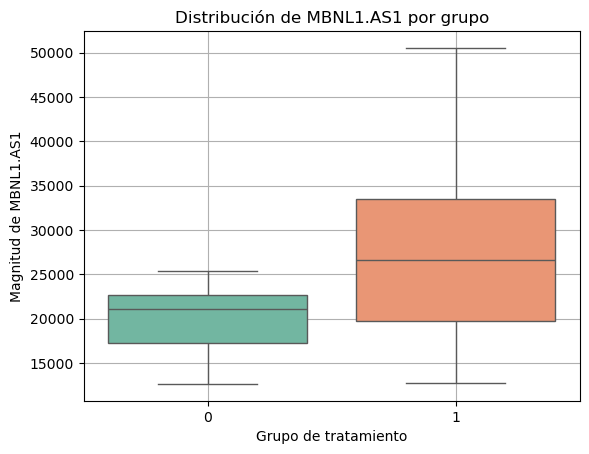

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\3162218130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1a,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


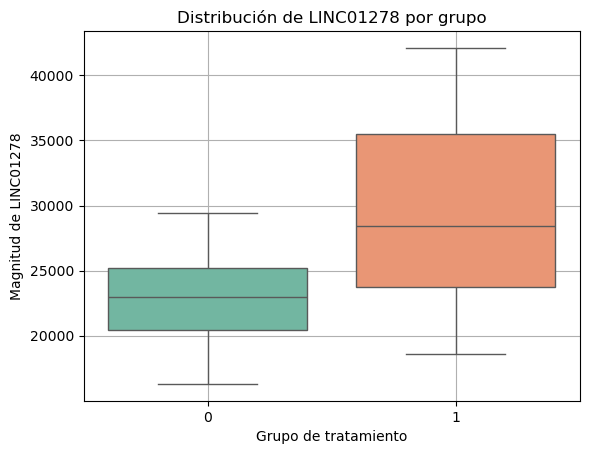

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\3162218130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1a,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


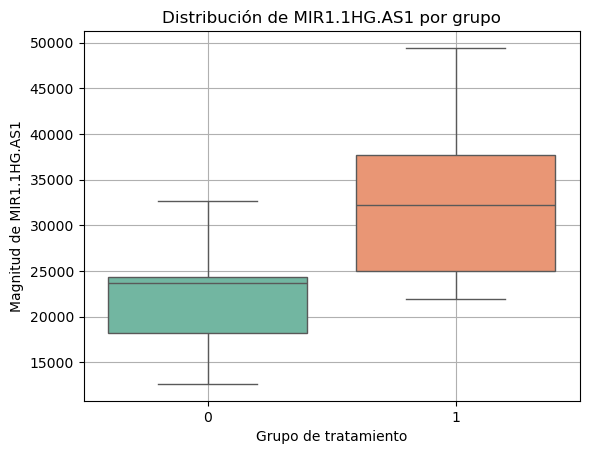

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\3162218130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1a,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


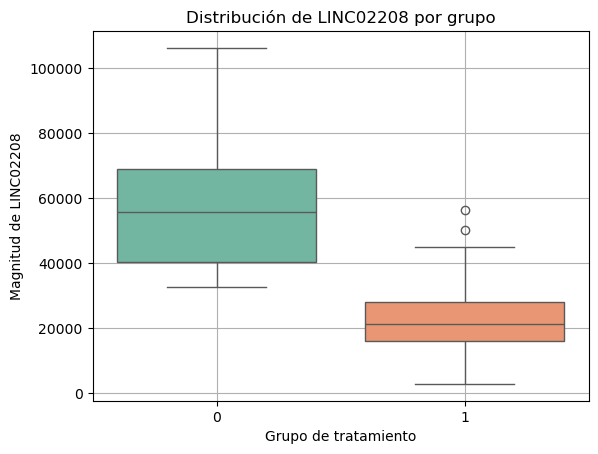

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\3162218130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1a,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


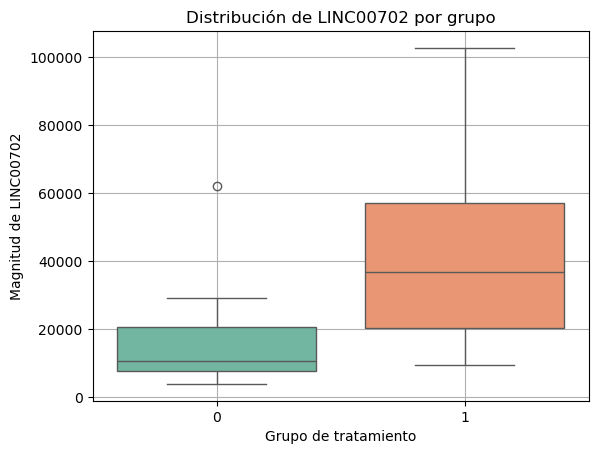

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\3162218130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1a,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


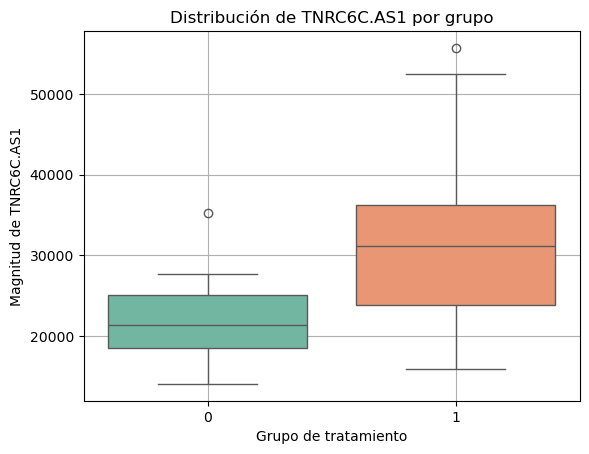

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\3162218130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1a,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


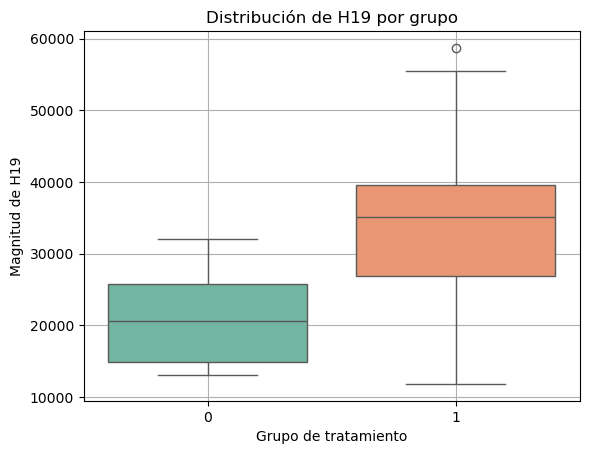

In [326]:
for col in df1a.columns:
    if col != 'Grupo_Tratamiento':
        sns.boxplot(data=df1a, 
                    x='Grupo_Tratamiento', 
                    y=col, 
                    palette='Set2')

        plt.xlabel('Grupo de tratamiento')
        plt.ylabel(f'Magnitud de {col}')
        plt.title(f'Distribución de {col} por grupo')
        plt.grid(True)
        plt.savefig(f"../graphics/boxplot_{col}_gnral.png", bbox_inches='tight', dpi=300)
        plt.show()

In [327]:
info_Adicional = pd.read_csv('../mRNA_seq/pacientesInfoAdicional.csv',sep = ';')
info_Adicional['Sexo'] = info_Adicional['Sexo'].str.lower()
info_Adicional['Sexo'] = pd.get_dummies(info_Adicional['Sexo']).astype(int)['hombre']
info_Adicional['Grupo_Tratamiento'] = pd.get_dummies(info_Adicional['Condición']).astype(int)['estenosis aórtica']
info_Adicional = info_Adicional.drop('Condición', axis = 1).rename(columns = {'ID muestra' : 'index'})
df1b = df1a.reset_index()
df1b['index'] = df1b['index'].str.replace("Raw_", "", regex=False)
df1c = pd.merge(info_Adicional[['index','Sexo']],df1b, on = 'index', how = 'inner').set_index('index')

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1c_fem,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:17: 

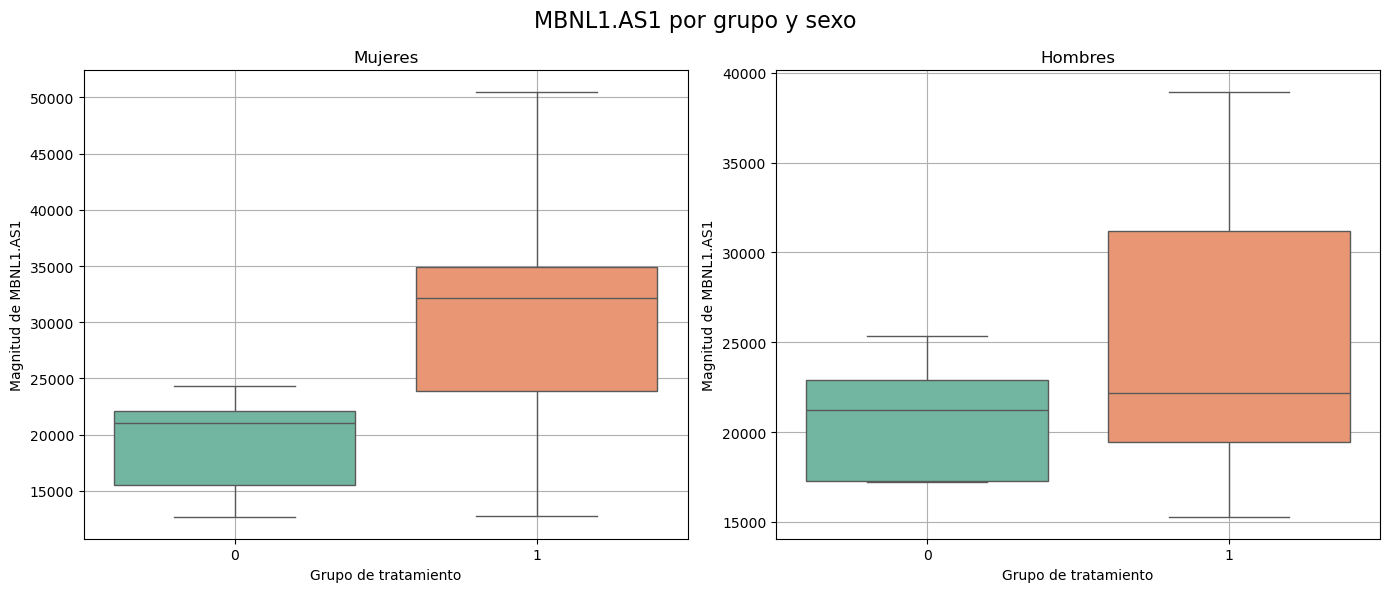

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1c_fem,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:17: 

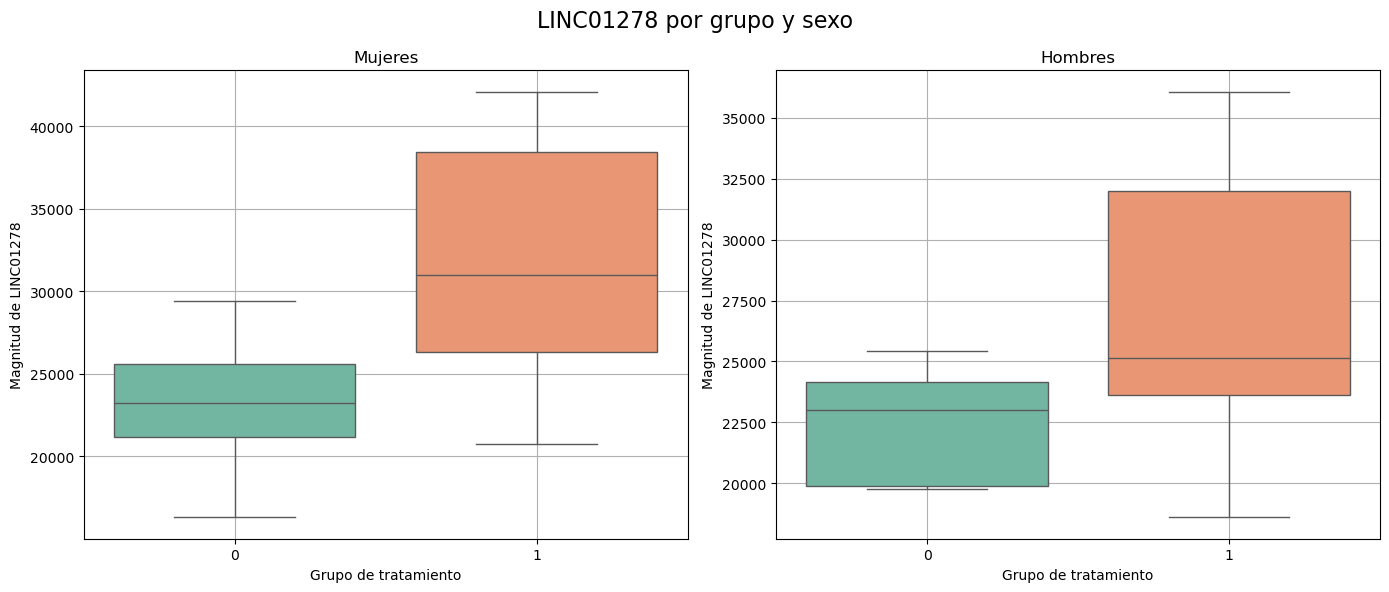

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1c_fem,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:17: 

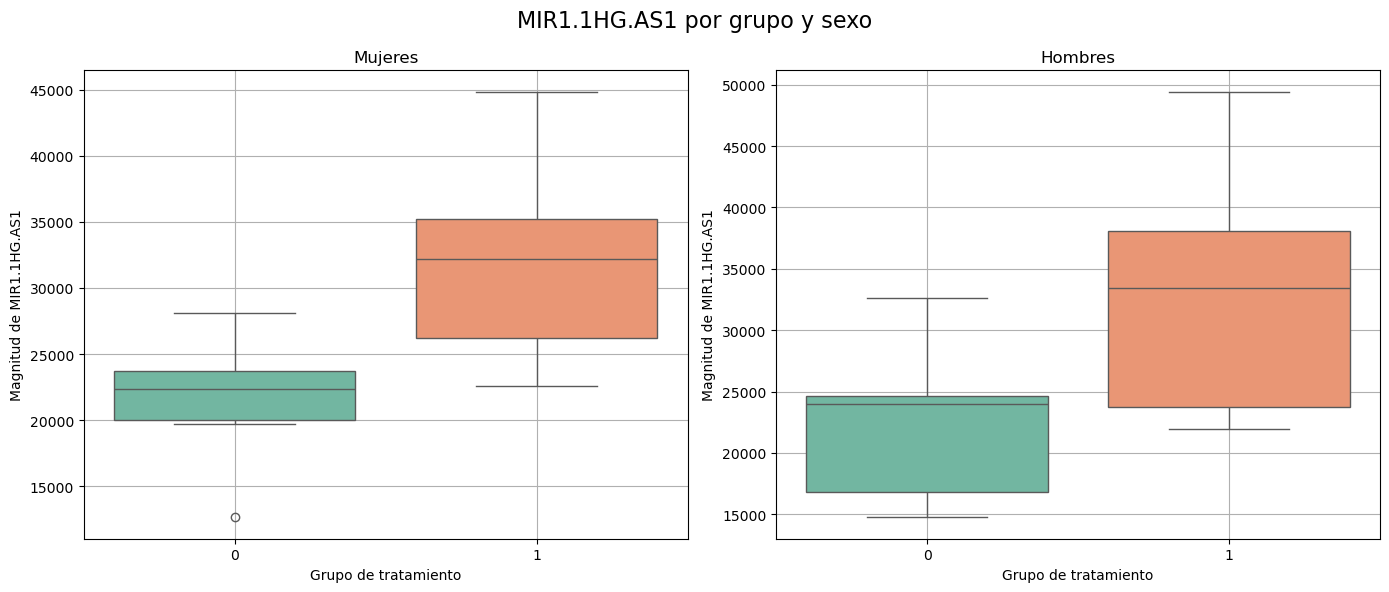

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1c_fem,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:17: 

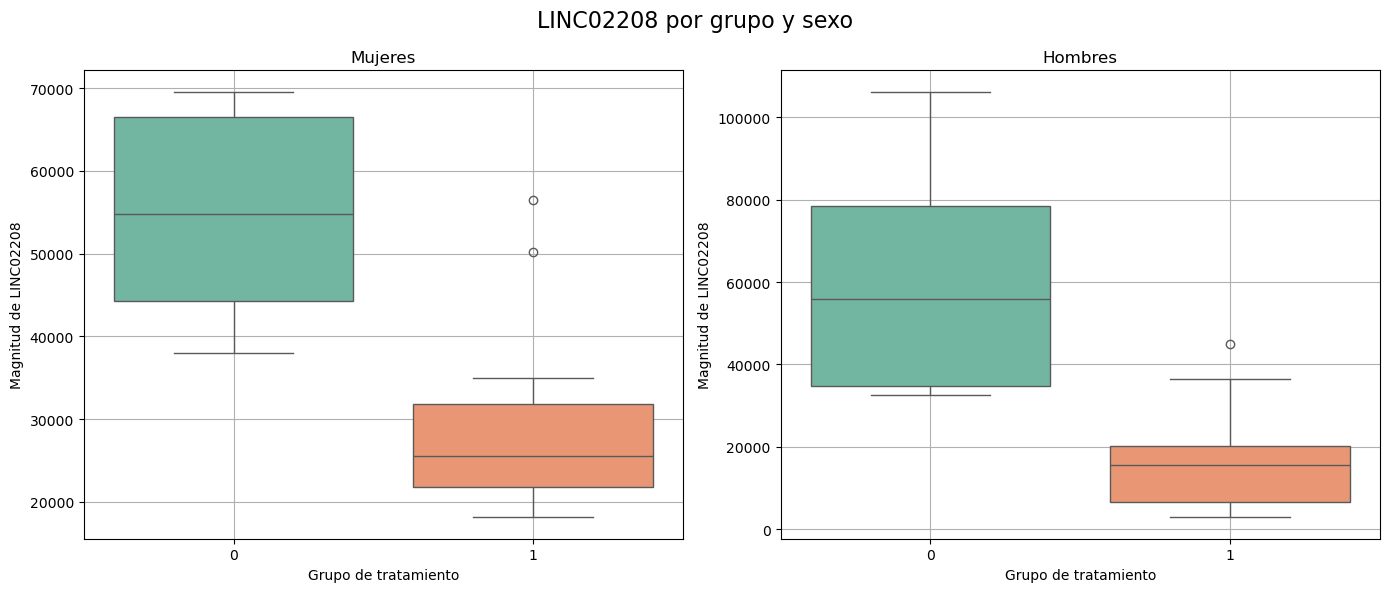

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1c_fem,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:17: 

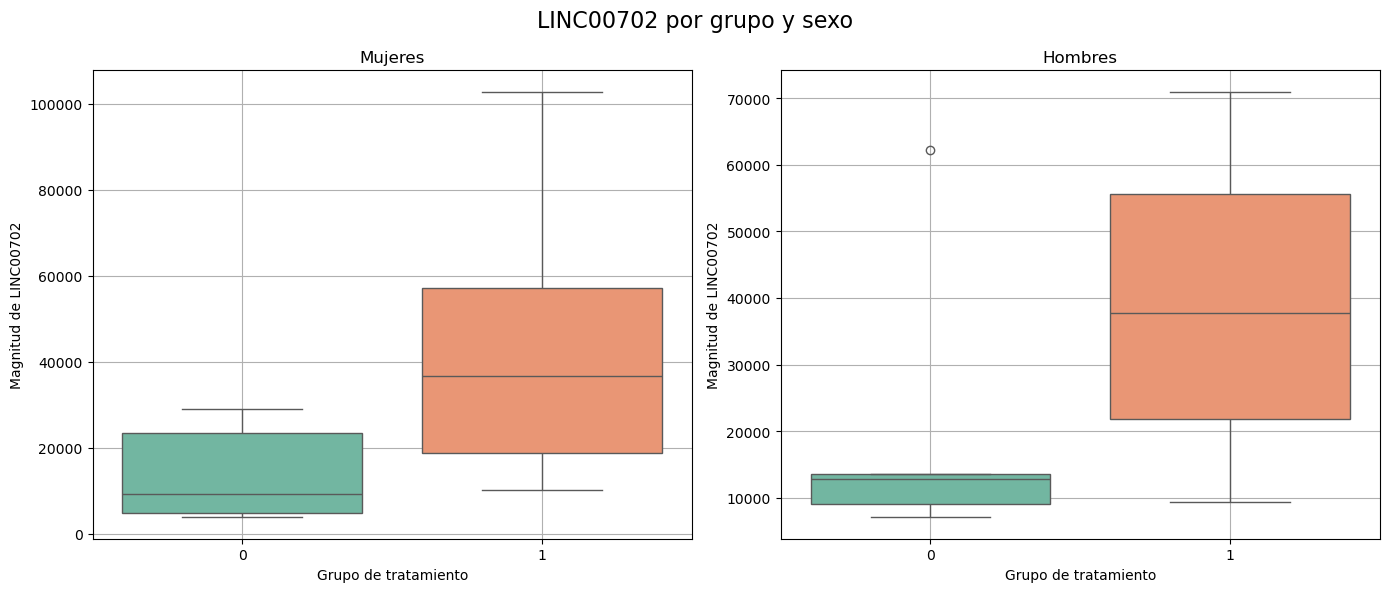

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1c_fem,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:17: 

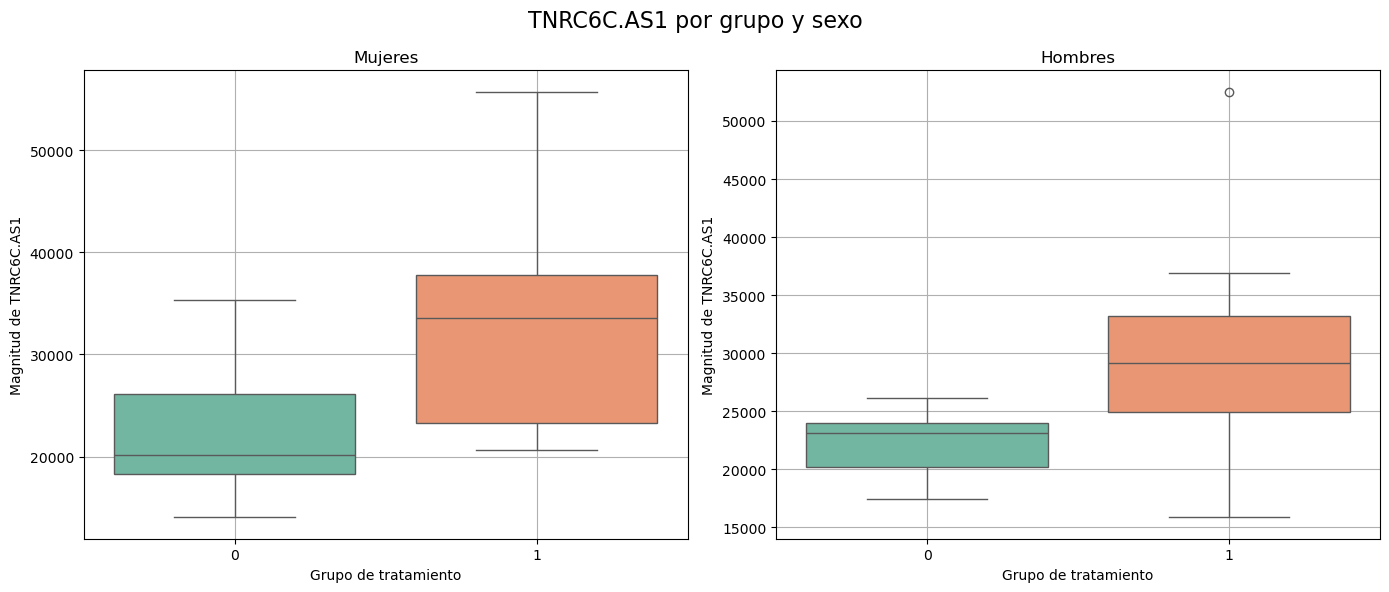

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1c_fem,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\2143829616.py:17: 

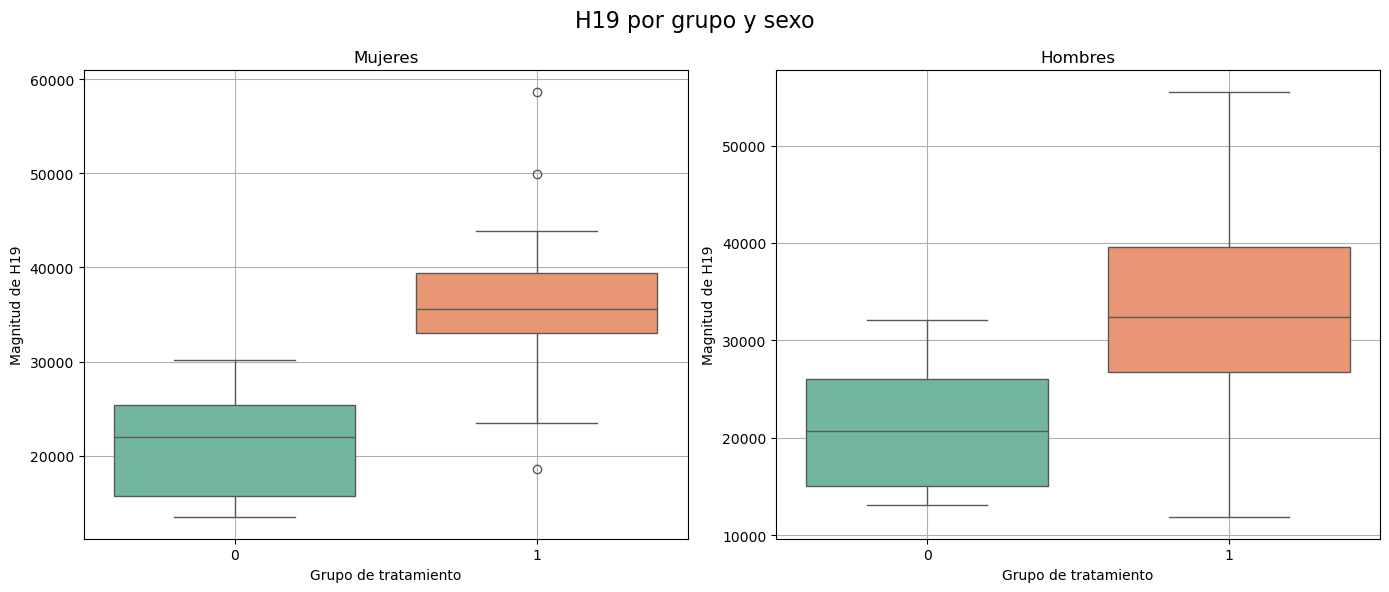

In [328]:
for col in df1c.columns:
    if col not in ['Grupo_Tratamiento', 'Sexo']:
        df1c_fem= df1c[df1c['Sexo'] == 0]
        df1c_masc= df1c[df1c['Sexo'] == 1]

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        sns.boxplot(data=df1c_fem, 
                    x='Grupo_Tratamiento', 
                    y=col, 
                    palette='Set2', 
                    ax=axes[0])
        axes[0].set_xlabel('Grupo de tratamiento')
        axes[0].set_ylabel(f'Magnitud de {col}')
        axes[0].set_title('Mujeres', fontsize=12)
        axes[0].grid(True)

        sns.boxplot(data=df1c_masc, 
                    x='Grupo_Tratamiento', 
                    y=col, 
                    palette='Set2', 
                    ax=axes[1])
        axes[1].set_xlabel('Grupo de tratamiento')
        axes[1].set_ylabel(f'Magnitud de {col}')
        axes[1].set_title('Hombres', fontsize=12)
        axes[1].grid(True)
        fig.suptitle(f'{col} por grupo y sexo', fontsize=16)
        plt.tight_layout()
        plt.savefig(f"../graphics/boxplot_{col}_hombresMujeres.png", bbox_inches='tight', dpi=300)
        plt.show()

In [652]:
df2.columns

Index(['MBNL1.AS1', 'LINC01278', 'MIR1.1HG.AS1', 'LINC02208', 'LINC00702',
       'TNRC6C.AS1', 'H19'],
      dtype='object')

### Descartar variables redundantes

Podemos usar 0.75 como threshold

In [366]:
df_list = []
threshold = 0.7
correlaciones_vars = df1.corr(method = 'spearman') #usar mejor Spearman, rank correlation
columns_to_drop = set()

# Iterar sobre la matriz de correlación y eliminar las columnas con correlación > 0.95
for i in range(len(correlaciones_vars.columns)):
    for j in range(i):
        if abs(correlaciones_vars.iloc[i, j]) > threshold:
            colname = correlaciones_vars.columns[i]
            columns_to_drop.add(colname)
nvarsAntes = len(df1.columns)        
df2 = df1.drop(columns=columns_to_drop)   
print(len(df1.columns),'variables →',len(df2.columns),'variables')

7 variables → 5 variables


### Árbol de clasificación

In [29]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

In [389]:
df2 = df_norm_TMM[variablesIncluir]

In [390]:
df3 = df2.copy().reset_index()
df3['Grupo'] = np.where(df3['index'].str.contains('A'), 'Tratamiento', 
              np.where(df3['index'].str.contains('C'), 'Control', 'Otro'))
df3 = df3.set_index('index')
df3 = pd.get_dummies(df3, columns=['Grupo'], drop_first=True)
df3['Grupo_Tratamiento'] = df3['Grupo_Tratamiento'].astype(int)

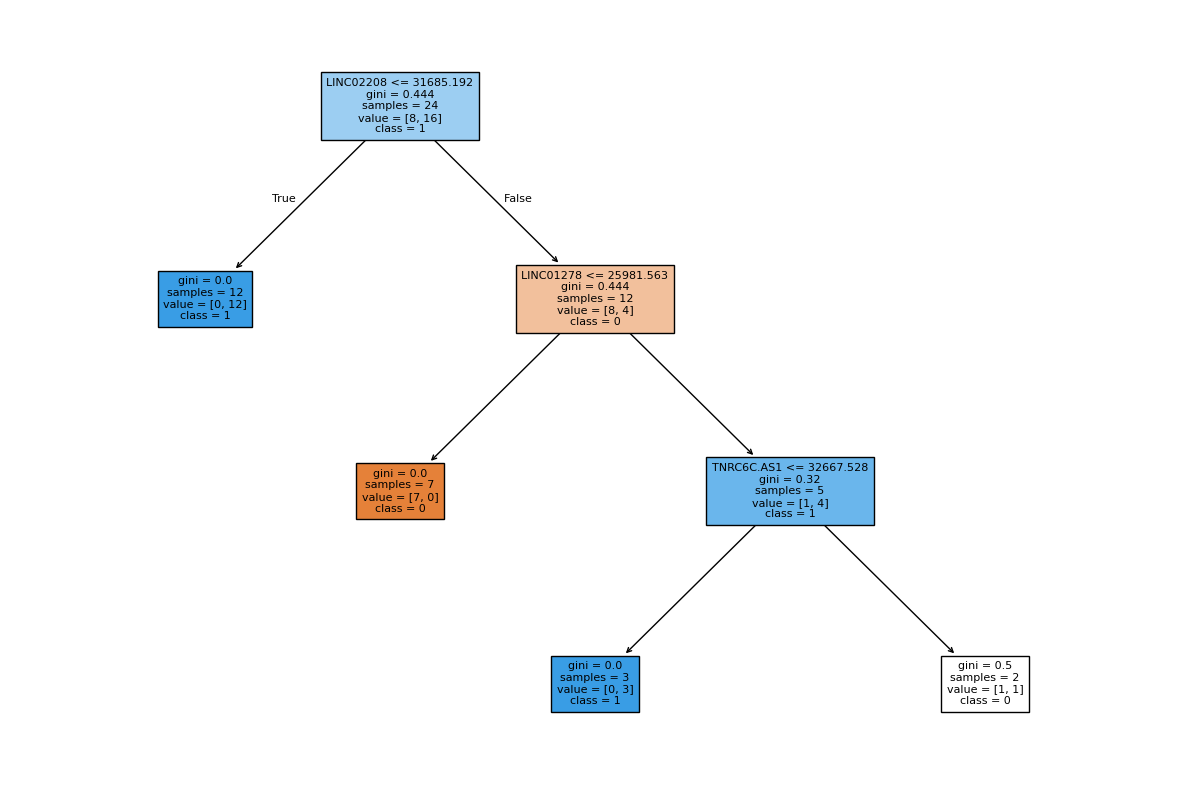

In [391]:
X = df3.drop(columns=["Grupo_Tratamiento"])  
y = df3["Grupo_Tratamiento"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear y entrenar el modelo
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Evaluar
accuracy = clf.score(X_test, y_test)

plt.figure(figsize=(12, 8))
plot_tree(
    clf,
    filled=True,
    feature_names=X.columns,
    class_names=[str(c) for c in clf.classes_],
    fontsize=8  # Tamaño de fuente más pequeño
)
plt.tight_layout() 
plt.show()


LINC02208
MBNL1.AS1

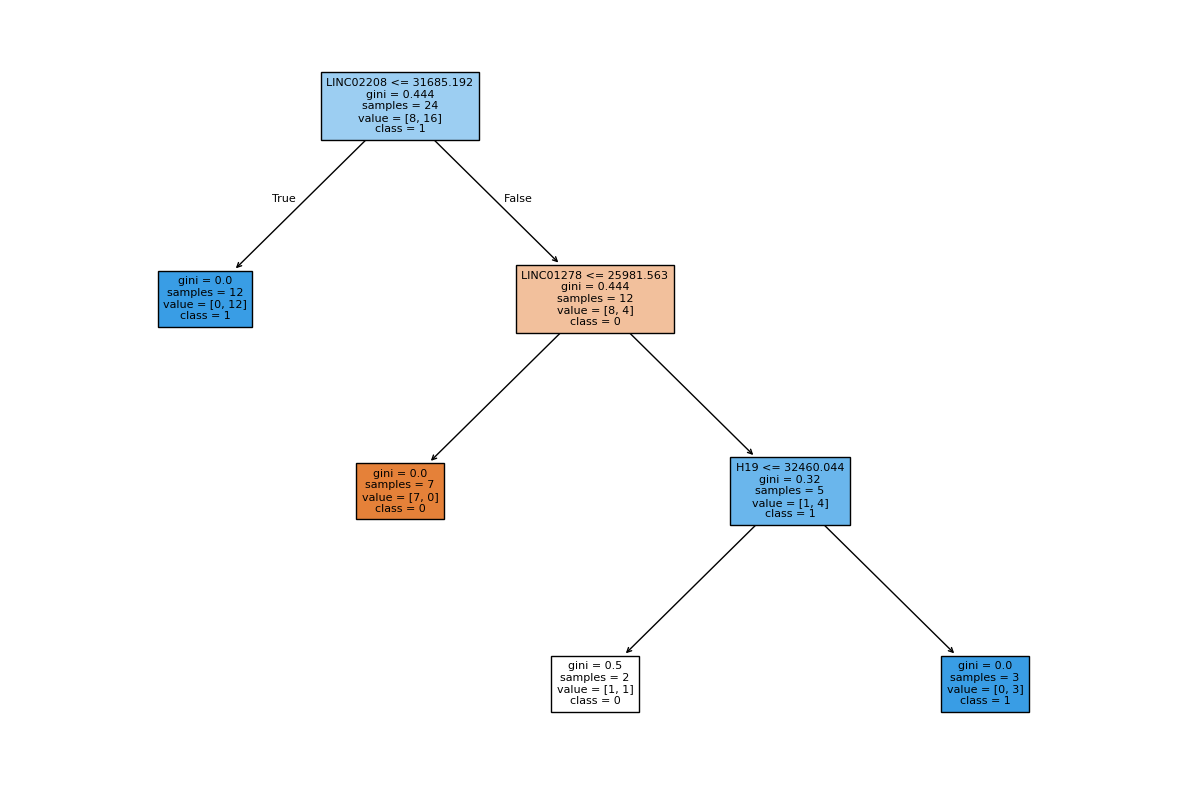

In [392]:
X = df3.drop(columns=["Grupo_Tratamiento","MBNL1.AS1"])  
y = df3["Grupo_Tratamiento"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear y entrenar el modelo
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Evaluar
accuracy = clf.score(X_test, y_test)

plt.figure(figsize=(12, 8))
plot_tree(
    clf,
    filled=True,
    feature_names=X.columns,
    class_names=[str(c) for c in clf.classes_],
    fontsize=8  # Tamaño de fuente más pequeño
)
plt.tight_layout() 
plt.show()

### Random Forest

In [393]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score,cross_val_predict, train_test_split
from sklearn.metrics  import roc_curve, auc, accuracy_score,confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [ ]:
df3 = df2.copy().reset_index()
df3['Grupo'] = np.where(df3['index'].str.contains('A'), 'Tratamiento', 
              np.where(df3['index'].str.contains('C'), 'Control', 'Otro'))
df3 = df3.set_index('index')
df3 = pd.get_dummies(df3, columns=['Grupo'], drop_first=True)
df3['Grupo_Tratamiento'] = df3['Grupo_Tratamiento'].astype(int)

c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-pa

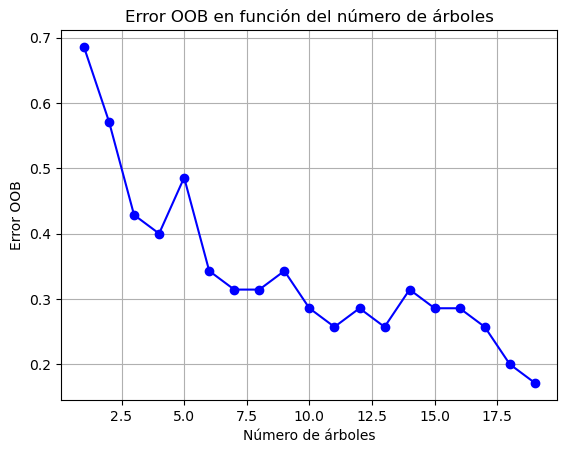

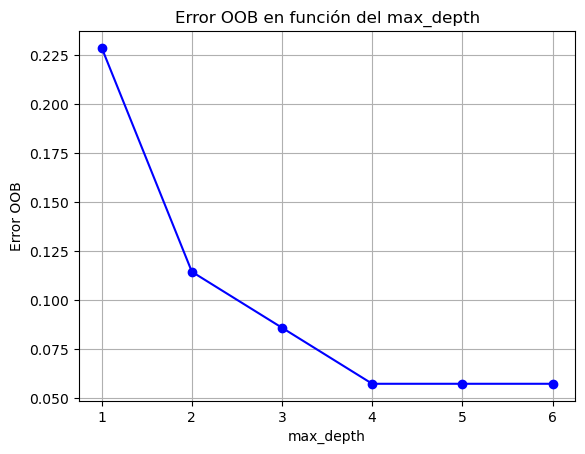

In [395]:
X = df3.drop(columns=["Grupo_Tratamiento"])  
y = df3["Grupo_Tratamiento"]
estimadores = range(1, 20, 1)
oob_errors = []

for n_estimators in estimadores:  
    rf = RandomForestClassifier(n_estimators=n_estimators, oob_score=True, random_state=42)
    rf.fit(X, y)
    oob_errors.append(1 - rf.oob_score_) 

plt.plot(estimadores, oob_errors, marker='o', color='b')
plt.xlabel('Número de árboles')
plt.ylabel('Error OOB')
plt.title('Error OOB en función del número de árboles')
plt.grid(True)
plt.show()

oob_errors = []
profundidades = range(1, 7)
for max_depth in profundidades:  
    rf = RandomForestClassifier(n_estimators=200, max_depth=max_depth, oob_score=True, random_state=42)
    rf.fit(X, y)
    oob_errors.append(1 - rf.oob_score_) 

plt.plot(profundidades, oob_errors, marker='o', color='b')
plt.xlabel('max_depth')
plt.ylabel('Error OOB')
plt.title('Error OOB en función del max_depth')
plt.grid(True)
plt.show()

In [483]:
from sklearn.preprocessing import MinMaxScaler

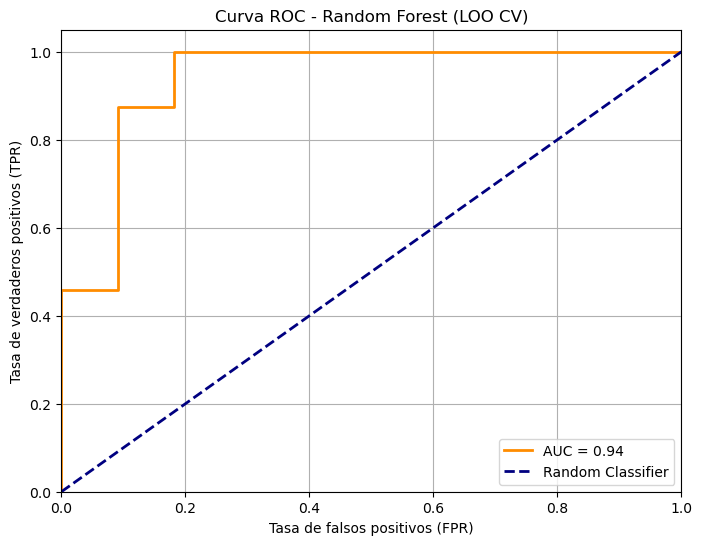

Precisión media en entrenamiento: 0.9722689075630251
Precisión media en test: 0.9142857142857143
AUC de la curva ROC: 0.9393939393939393
Tasa de verdaderos negativos (TNR - especificidad): 0.7272727272727273
Tasa de falsos negativos (FNR): 0.0
Tasa de verdaderos  positivos (TPR): 1.0
Tasa de falsos positivos (FPR): 0.2727272727272727
LINC02208       0.238327
H19             0.207213
LINC00702       0.175087
MIR1.1HG.AS1    0.124507
LINC01278       0.102011
MBNL1.AS1       0.080898
TNRC6C.AS1      0.071956
dtype: float64


In [613]:
n_estimators = 100
max_depth = 2

X = df3.drop(columns=["Grupo_Tratamiento"])  
y = df3["Grupo_Tratamiento"]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # Estándariza X sin la constante

X = pd.DataFrame(X_scaled, columns=X.columns,index = y.index)
# Inicializar LOO
loo = LeaveOneOut()

# Acumuladores
accuracies_train = []
accuracies_test = []
y_true = []
y_pred_proba = []
y_pred_class = []
modelos = []
importancias = []
# Loop LOO
for train_index, test_index in loo.split(X):
    rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, oob_score=True, random_state=42)
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    
    rf.fit(X_train, y_train)

    # Predicciones
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    y_test_proba = rf.predict_proba(X_test)[:, 1]

    # Guardar resultados
    accuracies_train.append(accuracy_score(y_train, y_train_pred))
    accuracies_test.append(accuracy_score(y_test, y_test_pred))
    y_true.append(y_test.values[0])
    y_pred_proba.append(y_test_proba[0])
    y_pred_class.append(y_test_pred[0])
    importances = rf.feature_importances_
    feature_names = X.columns
    feat_importances = pd.DataFrame(importances, index=feature_names).T
    importancias.append(feat_importances)
    modelos.append(rf)
importancias = pd.concat(importancias)
# Calcular AUC y ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Matriz de confusión agregada
cm = confusion_matrix(y_true, y_pred_class)
TN, FP, FN, TP = cm.ravel()

# Métricas adicionales
TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

# Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest (LOO CV)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Resultados
print("Precisión media en entrenamiento:", np.mean(accuracies_train))
print("Precisión media en test:", np.mean(accuracies_test))
print("AUC de la curva ROC:", roc_auc)
print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
print("Tasa de falsos negativos (FNR):", FNR)
print("Tasa de verdaderos  positivos (TPR):", TPR)
print("Tasa de falsos positivos (FPR):", FPR)
print(importancias.mean().sort_values(ascending = False))

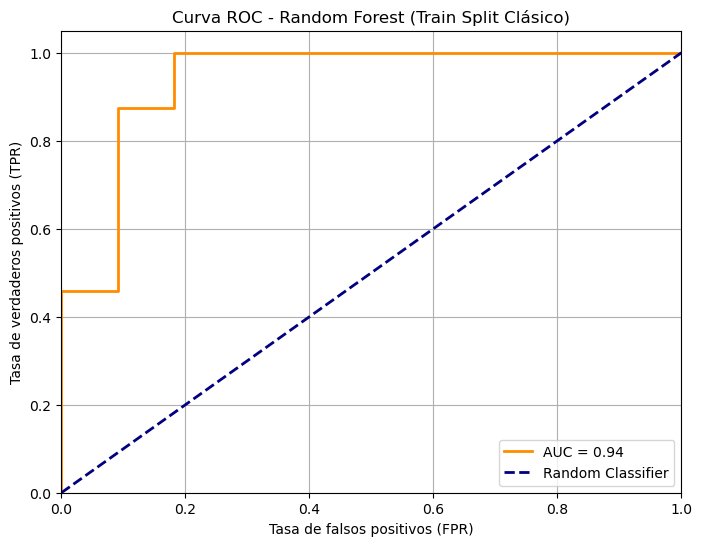

Precisión media en entrenamiento: 0.9722689075630251
Precisión media en test: 0.9142857142857143
AUC de la curva ROC: 0.9393939393939393
Tasa de verdaderos negativos (TNR - especificidad): 0.7272727272727273
Tasa de falsos negativos (FNR): 0.0
Tasa de verdaderos  positivos (TPR): 1.0
Tasa de falsos positivos (FPR): 0.2727272727272727


In [648]:
n_estimators = 50
max_depth = 2

X = df3.drop(columns=["Grupo_Tratamiento"])  
y = df3["Grupo_Tratamiento"]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # Estándariza X sin la constante

X = pd.DataFrame(X_scaled, columns=X.columns,index = y.index)

rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, oob_score=True, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # datos
    test_size=0.2,          # 20% para test, 80% para entrenamiento
)

rf.fit(X_train, y_train)

# Predicciones
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)
y_test_proba = rf.predict_proba(X_test)[:, 1]


importances = rf.feature_importances_
feature_names = X.columns
feat_importances = pd.DataFrame(importances, index=feature_names).T

# Calcular AUC y ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Matriz de confusión agregada
cm = confusion_matrix(y_true, y_pred_class)
TN, FP, FN, TP = cm.ravel()

# Métricas adicionales
TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

# Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest (Train Split Clásico)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Resultados
print("Precisión media en entrenamiento:", np.mean(accuracies_train))
print("Precisión media en test:", np.mean(accuracies_test))
print("AUC de la curva ROC:", roc_auc)
print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
print("Tasa de falsos negativos (FNR):", FNR)
print("Tasa de verdaderos  positivos (TPR):", TPR)
print("Tasa de falsos positivos (FPR):", FPR)

#### Interpretaciones de RF

In [561]:
importancias.mean().sort_values(ascending = False)

LINC02208       0.238327
H19             0.207213
LINC00702       0.175087
MIR1.1HG.AS1    0.124507
LINC01278       0.102011
MBNL1.AS1       0.080898
TNRC6C.AS1      0.071956
dtype: float64

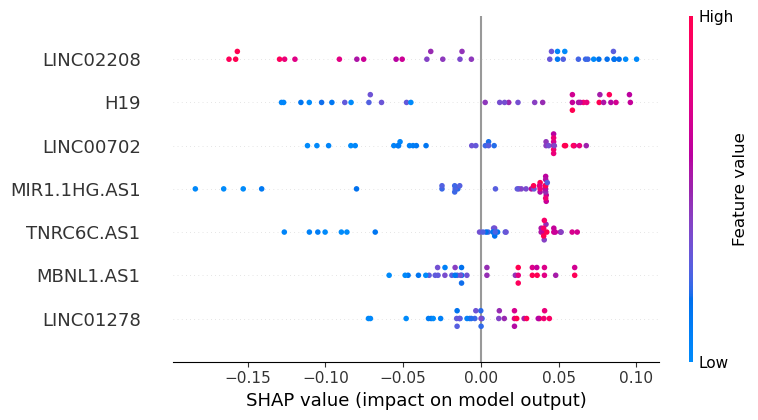

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Gráfico resumen
shap.summary_plot(shap_values[:, :, 1], X)


#### Gráficos dependencia de una variable específica

Eje X: valores reales de Variable

Eje Y: impacto SHAP sobre la predicción de ser clase 1

Color: por defecto es otra variable correlacionada (puedes forzar una específica con interaction_index)

In [647]:
for i in X.columns:
    shap.dependence_plot(i, shap_values[:, :, 1], X, show=False)
    plt.savefig(f'../graphics/shap_dependence_{i}.png', bbox_inches='tight', dpi=300)
    plt.close() 

In [564]:
from sklearn.tree import _tree

info_nodos_raiz = []

for i, tree in enumerate(rf.estimators_):
    t = tree.tree_
    for feat in range(len(t.feature)):
        if t.feature[feat] > 0:    
            feature_index = t.feature[feat]  
            gini_izq = t.impurity[t.children_left[feat]]
            gini_der = t.impurity[t.children_right[feat]]
            threshold = t.threshold[feat]            
            n_samples_izq = t.n_node_samples[t.children_left[feat]]        
            value_izq = t.value[t.children_left[feat]][0]
            n_samples_der = t.n_node_samples[t.children_right[feat]]               
            value_der = t.value[t.children_right[feat]][0]
            variable = X.columns[feature_index] if feature_index != _tree.TREE_UNDEFINED else "Undefined"
            
            info_nodos_raiz.append({
                "árbol": i,
                "variable": variable,
                "umbral": threshold,
                "ceros_izq" : value_izq[0],
                "unos_izq" : value_izq[1],
                "ceros_der" : value_der[0],
                "unos_der" : value_der[1],
                "gini_izq" : gini_izq,
                "gini_der" : gini_der
            })
df_nodos_raiz = pd.DataFrame(info_nodos_raiz)

In [375]:
from collections import Counter

feature_names = X.columns
idx_mbnl1 = list(feature_names).index("MBNL1.AS1")
idx_h19 = list(feature_names).index("H19")
# Inicializar contador
contador_mbnl1_mayor = 0
total_comparaciones = 0
mbnl1_importancias = []
h19_importancias = []
modelos_mbnl1_mayor = {}
# Por cada modelo de RF
for modelo in range(len(modelos)):
    # Por cada árbol en el modelo
    arboles_mbnl1_mayor = 0
    for arbol in modelos[modelo].estimators_:
        imp = arbol.feature_importances_
        imp_mbnl1 = imp[idx_mbnl1]
        imp_h19 = imp[idx_h19]
        if imp[idx_mbnl1] > imp[idx_h19]: #si el indice de MBNL1.AS1 es mas importante que el de H19, lo contamos como tal
            contador_mbnl1_mayor += 1
            arboles_mbnl1_mayor += 1
            mbnl1_importancias.append(imp_mbnl1)
            h19_importancias.append(imp_h19)
        total_comparaciones += 1
    modelos_mbnl1_mayor.update({modelo : arboles_mbnl1_mayor/100})

# Proporción
proporcion = contador_mbnl1_mayor / total_comparaciones
prom_mbnl1 = sum(mbnl1_importancias) / len(mbnl1_importancias)
prom_h19 = sum(h19_importancias) / len(h19_importancias)

In [377]:
print(f"Proporción de veces que MBNL1.AS1 > H19: {proporcion:.4f}") #Sobre la proporcion en donde aparecen las dos variables
print(f"Promedio de importancia de MBNL1.AS1 en esos casos: {prom_mbnl1:.6f}")
print(f"Promedio de importancia de H19 en esos casos: {prom_h19:.6f}")
print(f"Proporción promedio de los árboles en donde MBNL1.AS1 > H19 para cada modelo: {float(np.mean(list(modelos_mbnl1_mayor.values()))):.6f}")

Proporción de veces que MBNL1.AS1 > H19: 0.2126
Promedio de importancia de MBNL1.AS1 en esos casos: 0.390516
Promedio de importancia de H19 en esos casos: 0.033398
Proporción promedio de los árboles en donde MBNL1.AS1 > H19 para cada modelo: 0.212571


In [378]:
df3.corr()['Grupo_Tratamiento']

MBNL1.AS1            0.406150
MIR1.1HG.AS1         0.557957
LINC02208           -0.702562
TNRC6C.AS1           0.421139
H19                  0.553399
Grupo_Tratamiento    1.000000
Name: Grupo_Tratamiento, dtype: float64

### Logistica

In [551]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

#### Logistica con discretización

In [553]:
def discretizar_variables(df, n_bins):
    """
    Discretiza las variables continuas usando una cantidad definida de intervalos.
    """
    df_discretized = df.copy()
    for col in df.columns:
        df_discretized[col] = pd.qcut(df[col], q=n_bins, labels=False, duplicates='drop')
    data_encoded = pd.DataFrame()
    for col in df_discretized.columns:
        dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
        dummies = dummies.drop(columns=[col + '_bajo'], errors='ignore')  # 'errors="ignore"' maneja el caso de que no exista esa columna
        data_encoded = pd.concat([data_encoded, dummies], axis=1)
    data_encoded = data_encoded.astype(int)

    return data_encoded

Exactitud: 1.00
AUC: 1.00


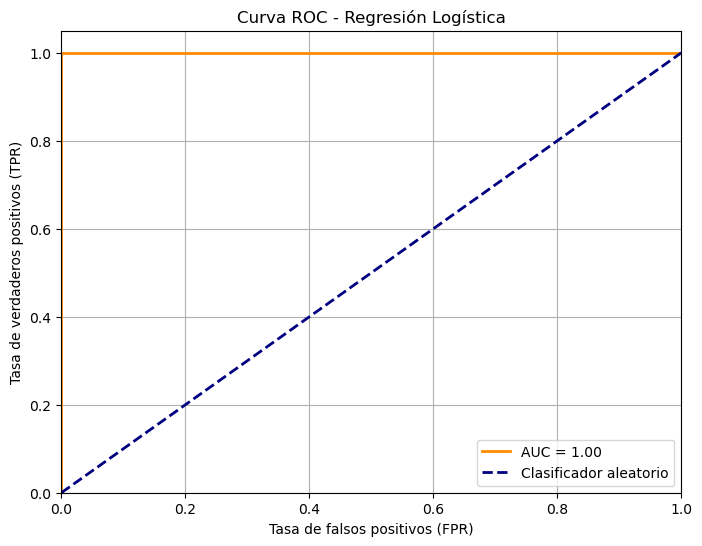

Coeficientes del modelo:
    Característica  Coeficiente
0      MBNL1.AS1_0     0.000000
1      MBNL1.AS1_1     0.000000
2      MBNL1.AS1_2     1.894242
3      LINC01278_0     0.000000
4      LINC01278_1     0.000000
5      LINC01278_2     0.000000
6   MIR1.1HG.AS1_0     0.000000
7   MIR1.1HG.AS1_1     0.000000
8   MIR1.1HG.AS1_2     0.386183
9      LINC02208_0     1.616564
10     LINC02208_1     0.000000
11     LINC02208_2    -1.061019
12     LINC00702_0    -0.082403
13     LINC00702_1     0.000000
14     LINC00702_2     0.000000
15    TNRC6C.AS1_0     0.000000
16    TNRC6C.AS1_1     0.000000
17    TNRC6C.AS1_2     0.190909
18           H19_0    -0.325088
19           H19_1     0.000000
20           H19_2     0.448127


In [606]:
df4 = discretizar_variables(df2, 3)
df4 = pd.concat([df4,df3['Grupo_Tratamiento']], axis = 1)

X = df4.drop(columns=["Grupo_Tratamiento"])  
y = df4["Grupo_Tratamiento"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(penalty='l1', solver='liblinear')

# Entrenar el modelo
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1] 

accuracy = accuracy_score(y_test, y_pred)
print(f'Exactitud: {accuracy:.2f}')



fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
print(f'AUC: {roc_auc:.2f}')

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


coefficients = pd.DataFrame({
    'Característica': X.columns,
    'Coeficiente': log_reg.coef_[0]
})
print("Coeficientes del modelo:")
print(coefficients)

In [650]:
coefficients

,Característica,Coeficiente
0,MBNL1.AS1_0,0.000000
1,MBNL1.AS1_1,0.000000
2,MBNL1.AS1_2,1.894242
3,LINC01278_0,0.000000
4,LINC01278_1,0.000000
5,LINC01278_2,0.000000
6,MIR1.1HG.AS1_0,0.000000
7,MIR1.1HG.AS1_1,0.000000
8,MIR1.1HG.AS1_2,0.386183
9,LINC02208_0,1.616564


In [641]:
coef_diffCero = coefficients[coefficients['Coeficiente'] != 0]
coef_diffCero['car_abs'] = coef_diffCero['Coeficiente'].abs()
coef_diffCero = coef_diffCero.sort_values(by = 'car_abs',ascending = False)
coef_diffCero = coef_diffCero.drop ('car_abs', axis = 1)


C:\Users\delatorrei\AppData\Local\Temp\ipykernel_5148\1775063592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coef_diffCero['car_abs'] = coef_diffCero['Coeficiente'].abs()


In [642]:
coef_diffCero

,Característica,Coeficiente
2,MBNL1.AS1_2,1.894242
9,LINC02208_0,1.616564
11,LINC02208_2,-1.061019
20,H19_2,0.448127
8,MIR1.1HG.AS1_2,0.386183
18,H19_0,-0.325088
17,TNRC6C.AS1_2,0.190909
12,LINC00702_0,-0.082403


In [638]:
importancias.mean().sort_values(ascending = False)

LINC02208       0.238327
H19             0.207213
LINC00702       0.175087
MIR1.1HG.AS1    0.124507
LINC01278       0.102011
MBNL1.AS1       0.080898
TNRC6C.AS1      0.071956
dtype: float64

valor Random Forest


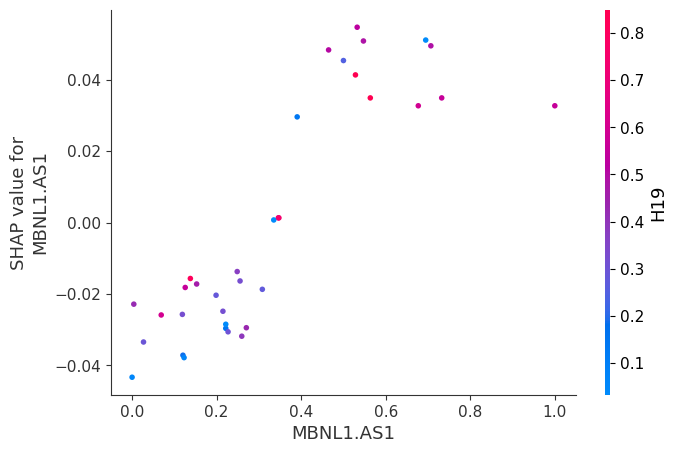

valor Logistica
  Característica  Coeficiente
2    MBNL1.AS1_2     1.894242
valor Random Forest


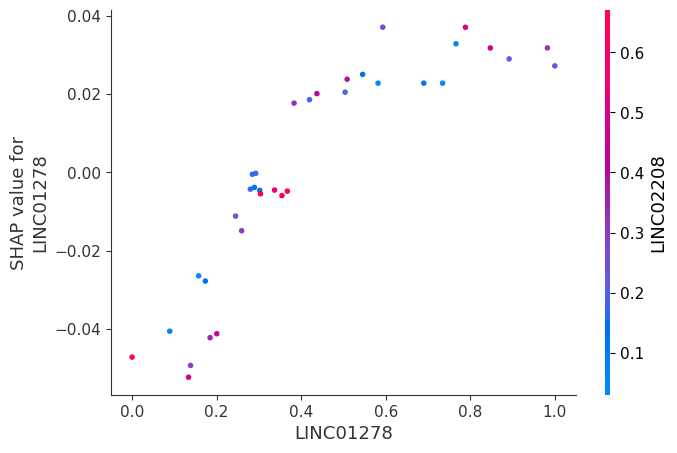

valor Logistica
Empty DataFrame
Columns: [Característica, Coeficiente]
Index: []
valor Random Forest


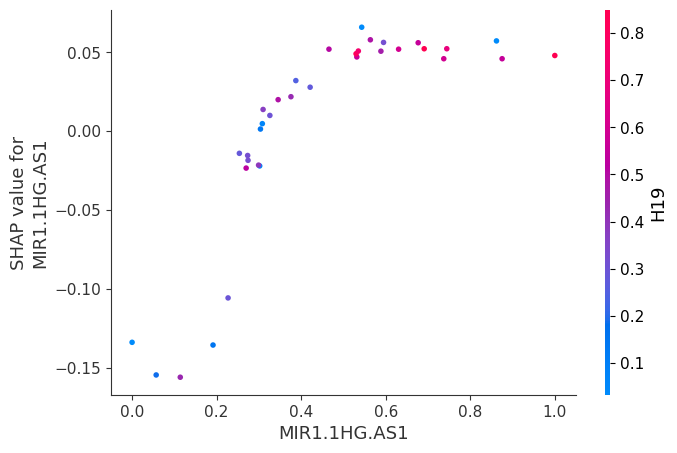

valor Logistica
   Característica  Coeficiente
8  MIR1.1HG.AS1_2     0.386183
valor Random Forest


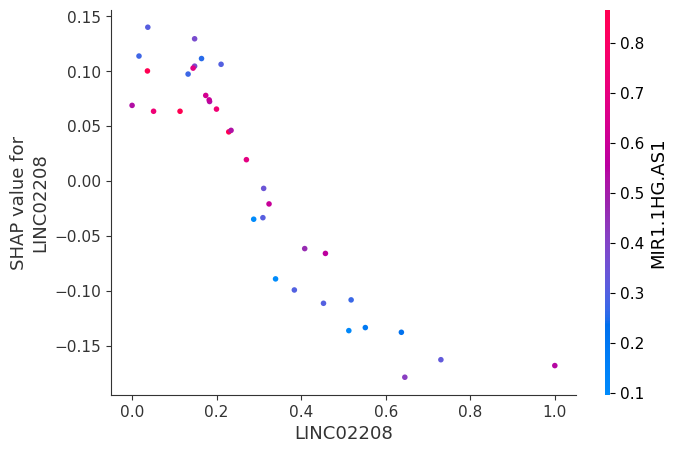

valor Logistica
   Característica  Coeficiente
9     LINC02208_0     1.616564
11    LINC02208_2    -1.061019
valor Random Forest


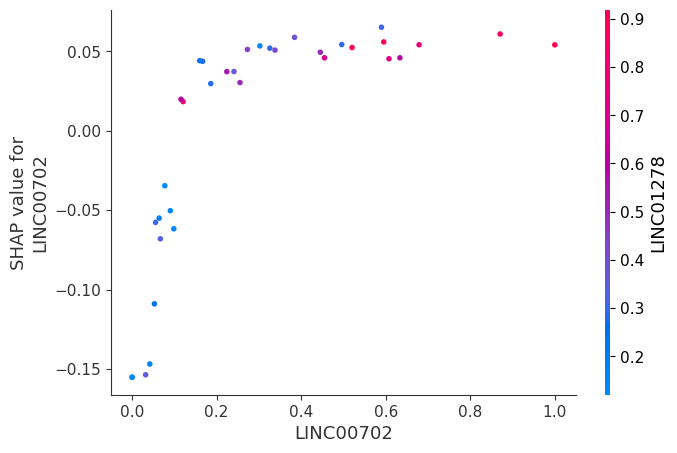

valor Logistica
   Característica  Coeficiente
12    LINC00702_0    -0.082403
valor Random Forest


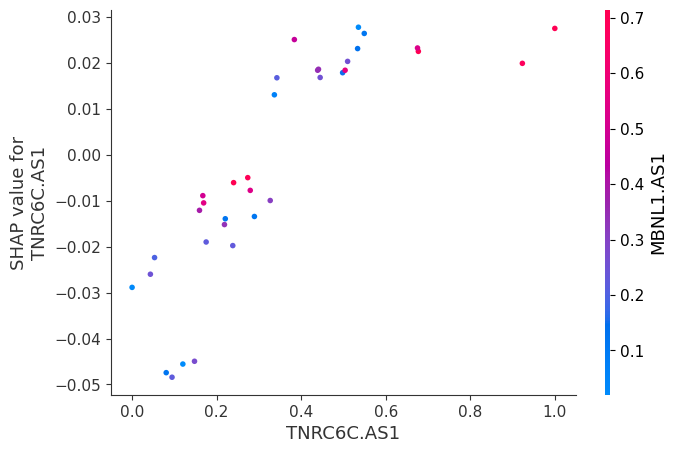

valor Logistica
   Característica  Coeficiente
17   TNRC6C.AS1_2     0.190909
valor Random Forest


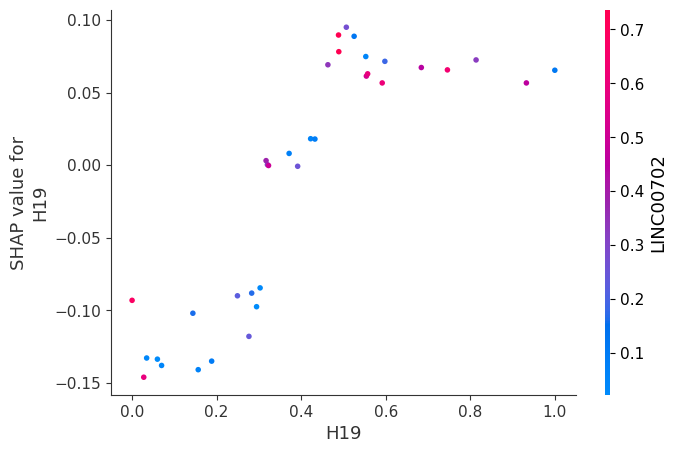

valor Logistica
   Característica  Coeficiente
20          H19_2     0.448127
18          H19_0    -0.325088


In [635]:

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Gráfico resumen
for i in X.columns:
    coefLogit = [j for j in coef_diffCero['Característica'].to_list() if i in j]
    print("valor Random Forest")
    shap.dependence_plot(i, shap_values[:, :, 1], X)
    print("valor Logistica")
    print(coef_diffCero[coef_diffCero['Característica'].isin(coefLogit)])
    

### Red Bayesiana

In [129]:
from pgmpy.estimators import HillClimbSearch, MaximumLikelihoodEstimator,BIC
from pgmpy.models import DiscreteBayesianNetwork 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer

In [66]:
df2 = df1.reset_index()
df2['Grupo'] = np.where(df2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df2['index'].str.contains('C'), 'Control', 'Otro'))
df2 = df2.set_index('index')
df2 = pd.get_dummies(df2, columns=['Grupo'], drop_first=True)
df2['Grupo_Tratamiento'] = df2['Grupo_Tratamiento'].astype(int)
X = df2.drop({'Grupo_Tratamiento'}, axis = 1)
Y = df2[['Grupo_Tratamiento']]

In [135]:
def calcular_informacion_mutua(X, y):
    """
    Calcula la información mutua entre una variable continua y una variable objetivo.
    """
    mi_scores = {}
    for col in X.columns:
        mi = mutual_info_score(X[col], y)
        mi_scores.update({col : mi})
    return mi_scores

def discretizar_variables(df, n_bins):
    """
    Discretiza las variables continuas usando una cantidad definida de intervalos.
    """
    df_discretized = df.copy()
    for col in df.columns:
        df_discretized[col] = pd.qcut(df[col], q=n_bins, labels=False, duplicates='drop')
    data_encoded = pd.DataFrame()
    for col in df_discretized.columns:
        dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
        dummies = dummies.drop(columns=[col + '_bajo'], errors='ignore')  # 'errors="ignore"' maneja el caso de que no exista esa columna
        data_encoded = pd.concat([data_encoded, dummies], axis=1)
    data_encoded = data_encoded.astype(int)

    return data_encoded

def discretizacion_basada_en_mi(df, y, k1=10, k2=3):
    """
    Discretiza las variables explicativas en base a la información mutua.
    - df: DataFrame con las variables explicativas.
    - y: Variable dependiente.
    - k1: Número inicial de intervalos para discretización.
    - k2: Número final de intervalos para discretización (cuando k2 << k1).
    """
    # Paso 1: Discretización inicial con k1 intervalos
    X_discretized = discretizar_variables(df, k1)
    
    # Paso 2: Calcular la información mutua inicial
    mi_scores = calcular_informacion_mutua(X_discretized, y)
    
    # Paso 3: Iterar y ajustar la discretización
    while len(set(mi_scores)) > k2:  # Mientras el número de intervalos sea mayor que k2
        # Fusionamos los intervalos con baja MI
        for col in X_discretized.columns:
            # Agrupar los intervalos con menor MI
            X_discretized[col] = (X_discretized[col] // 2)  # Fusionamos los intervalos
        mi_scores = calcular_informacion_mutua(X_discretized, y)

    return X_discretized

In [140]:
df3 = discretizar_variables(df1, 3)

In [147]:
df4 = pd.concat([df3,df2['Grupo_Tratamiento']], axis = 1)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'MBNL1.AS1_0': 'N', 'MBNL1.AS1_1': 'N', 'MBNL1.AS1_2': 'N', 'MIR1.1HG.AS1_0': 'N', 'MIR1.1HG.AS1_1': 'N', 'MIR1.1HG.AS1_2': 'N', 'LINC02208_0': 'N', 'LINC02208_1': 'N', 'LINC02208_2': 'N', 'TNRC6C.AS1_0': 'N', 'TNRC6C.AS1_1': 'N', 'TNRC6C.AS1_2': 'N', 'H19_0': 'N', 'H19_1': 'N', 'H19_2': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'MBNL1.AS1_0': 'N', 'MBNL1.AS1_1': 'N', 'MBNL1.AS1_2': 'N', 'MIR1.1HG.AS1_0': 'N', 'MIR1.1HG.AS1_1': 'N', 'MIR1.1HG.AS1_2': 'N', 'LINC02208_0': 'N', 'LINC02208_1': 'N', 'LINC02208_2': 'N', 'TNRC6C.AS1_0': 'N', 'TNRC6C.AS1_1': 'N', 'TNRC6C.AS1_2': 'N', 'H19_0': 'N', 'H19_1': 'N', 'H19_2': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'MBNL1.AS1_0': 'N', 'MBNL1.AS1_1': 'N', 'M

  0%|          | 0/1000000 [00:00<?, ?it/s]

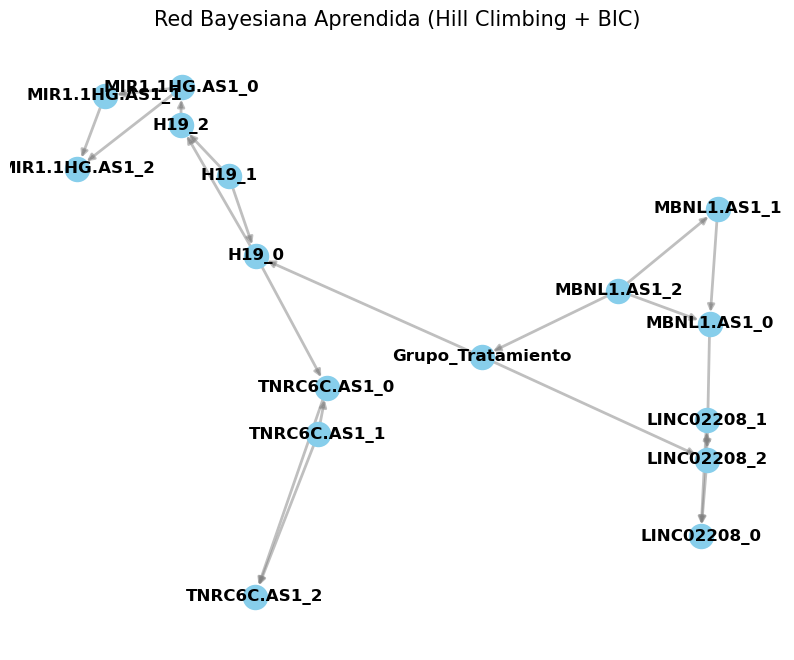

In [149]:
hc = HillClimbSearch(df4)
best_model = hc.estimate(scoring_method='bic-d')

edges = best_model.edges()
G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(10, 8))  # Tamaño del gráfico
pos = nx.spring_layout(G)  # Layout de la red (puedes cambiar el tipo)
nx.draw_networkx_nodes(G, pos,  node_color="skyblue")  # Dibujar los nodos
nx.draw_networkx_edges(G, pos, width=2.0, alpha=0.5, edge_color="gray",arrows = True)  # Dibujar las aristas
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold", font_color="black")  # Etiquetas

# Mostrar el gráfico
plt.title("Red Bayesiana Aprendida (Hill Climbing + BIC)", size=15)
plt.axis('off')  # Quitar los ejes para mejor presentación
plt.show()

In [95]:
df_discretized = X.copy()
for col in X.columns:
    df_discretized[col] = pd.qcut(X[col], q=5, labels=False, duplicates='drop')
data_encoded = pd.DataFrame()
for col in df_discretized.columns:
    dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
    data_encoded = pd.concat([data_encoded, dummies], axis=1)
data_encoded = data_encoded.astype(int)

In [134]:
mi_scores = {}
for col in data_encoded.columns:
    mi = mutual_info_score(data_encoded[col], y)
    mi_scores.update({col : mi})

NameError: name 'data_encoded' is not defined

In [101]:
X.columns

Index(['MBNL1.AS1', 'MIR1.1HG.AS1', 'LINC02208', 'TNRC6C.AS1', 'H19'], dtype='object')

In [102]:
substring = 'MBNL1.AS1'

# Filtrar el diccionario
filtrado = {k: v for k, v in mi_scores.items() if substring in k}

In [98]:
mi_scores = {}
for col in X.columns:
    mi = mutual_info_score(X[col], y)
    mi_scores.update({col : mi})
mi_scores

c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\delatorrei\Desktop\Proyectos\.conda\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for la

{'MBNL1.AS1': np.float64(0.6224869206570482),
 'MIR1.1HG.AS1': np.float64(0.6224869206570484),
 'LINC02208': np.float64(0.6224869206570482),
 'TNRC6C.AS1': np.float64(0.6224869206570484),
 'H19': np.float64(0.6224869206570484)}

In [ ]:
def redBayesianaHillClimbing(df_final, quantilesDiscretizacion, scoring_method='bic-d'):
    '''
    Primero discretizamos en base a los cuantiles. Si elegimos 2, cada variable se dividrá en dos, valores altos y bajo. Si elegimos 3, cada variable se dividirá en 3, valores altos, medios y bajos.
    Esta función hará tantas redes bayesianas como discretizaciones se haga, una para cada cuantil
    '''
    ##Discretización
    df_discretized = df_final.copy()
    for col in df_final.columns:
        df_discretized[col] = pd.qcut(df_final[col], q=quantilesDiscretizacion, labels=False, duplicates='drop')
    bayesianNtw_by_quantile = {}
    data_by_quantile = {}
    for quantile in range(quantilesDiscretizacion):
        quantile_df = df_discretized[df_discretized.apply(lambda row: row == quantile, axis=1)]
        
        data_encoded = pd.DataFrame()
        for col in quantile_df.columns:
            dummies = pd.get_dummies(quantile_df[col])
            dummies = dummies.rename(columns = {quantile : col})
            data_encoded = pd.concat([data_encoded, dummies], axis=1)
        data_by_quantile[quantile] = data_encoded.astype(int)

        ## Red bayesiana
        hc = HillClimbSearch(data_encoded)
        best_model = hc.estimate(scoring_method=scoring_method)
        bayesianNtw_by_quantile[quantile] = best_model
    return data_by_quantile,bayesianNtw_by_quantile

In [ ]:
def get_adjacency_matrix_from_dag(dag):
    """
    Función para obtener la matriz de adyacencia de un modelo DAG en pgmpy.
    """
    edges = dag.edges()
    nodes = dag.nodes()
    
    # Crear un diccionario que mapea los nodos a un índice
    node_to_index = {node: i for i, node in enumerate(nodes)}
    
    # Crear una matriz de adyacencia de tamaño (número de nodos) x (número de nodos)
    adj_matrix = np.zeros((len(nodes), len(nodes)))
    
    # Llenar la matriz de adyacencia con 1s en las posiciones correspondientes a las aristas
    for edge in edges:
        i = node_to_index[edge[0]]
        j = node_to_index[edge[1]]
        adj_matrix[i, j] = 1  # Desde edge[0] hacia edge[1]
    
    return adj_matrix

def compare_networks(model1, model2):
    from sklearn.metrics import jaccard_score
    # Obtener las matrices de adyacencia de las redes bayesianas
    adj_matrix_1 = get_adjacency_matrix_from_dag(model1)
    adj_matrix_2 = get_adjacency_matrix_from_dag(model2)

    # Comparar las matrices de adyacencia con una métrica como Jaccard
    jaccard = jaccard_score(adj_matrix_1.flatten(), adj_matrix_2.flatten(), average='binary')
    return jaccard

In [ ]:
quants = 3
data_by_quantile,bayesianNtw_by_quantile = redBayesianaHillClimbing(df_final, quants, scoring_method='bic-d')
for i in range(quants):
    for j in range(quants):
        if i != j:
            print('Coef Jaccard(modelo',i,'| modelo',j, '):',compare_networks(bayesianNtw_by_quantile[i], bayesianNtw_by_quantile[j]))
            

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

Coef Jaccard(modelo 0 | modelo 1 ): 0.2222222222222222
Coef Jaccard(modelo 0 | modelo 2 ): 0.23076923076923078
Coef Jaccard(modelo 1 | modelo 0 ): 0.2222222222222222
Coef Jaccard(modelo 1 | modelo 2 ): 0.1
Coef Jaccard(modelo 2 | modelo 0 ): 0.23076923076923078
Coef Jaccard(modelo 2 | modelo 1 ): 0.1


In [ ]:
###### Discretizamos
labels = ['bajo', 'medio', 'alto']
df_discretized = df_final.copy()
for col in df_final.columns:
    df_discretized[col] = pd.qcut(df_final[col], q=3, labels=labels, duplicates='drop')

data_encoded = pd.DataFrame()

for col in df_discretized.columns:
    dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
    data_encoded = pd.concat([data_encoded, dummies], axis=1)
data_encoded = data_encoded.astype(int)

In [ ]:
labels = ['bajo', 'alto']
df_discretized = df_final.copy()
for col in df_final.columns:
    df_discretized[col] = pd.qcut(df_final[col], q=2, labels=labels, duplicates='drop')

data_encoded = pd.DataFrame()

for col in df_discretized.columns:
    dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
    dummies = dummies.drop(columns=[col + '_bajo'], errors='ignore')  # 'errors="ignore"' maneja el caso de que no exista esa columna
    data_encoded = pd.concat([data_encoded, dummies], axis=1)
data_encoded = data_encoded.astype(int)
data_encoded.columns = data_encoded.columns.str.replace('_alto', '', regex=False)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

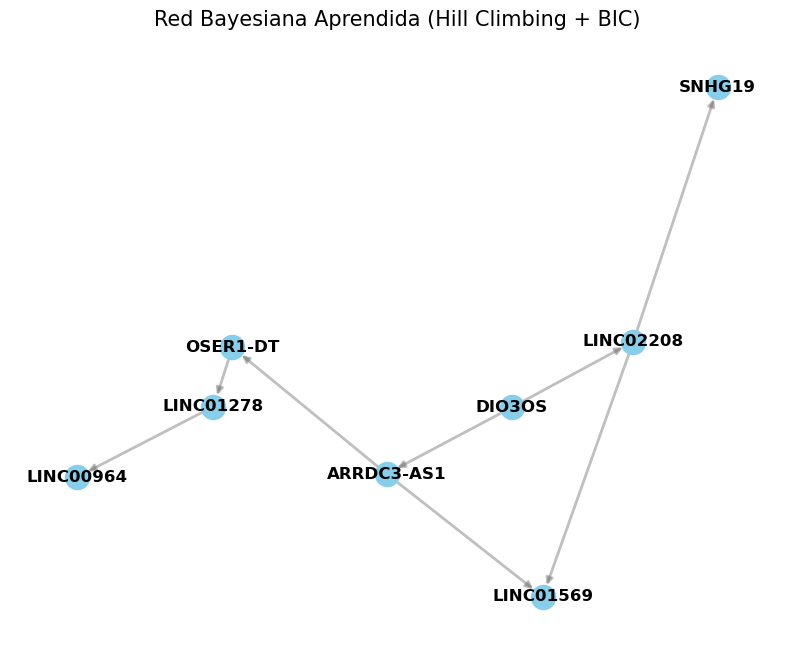

In [ ]:
hc = HillClimbSearch(data_encoded)
best_model = hc.estimate(scoring_method='bic-d')

edges = best_model.edges()
G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(10, 8))  # Tamaño del gráfico
pos = nx.spring_layout(G)  # Layout de la red (puedes cambiar el tipo)
nx.draw_networkx_nodes(G, pos,  node_color="skyblue")  # Dibujar los nodos
nx.draw_networkx_edges(G, pos, width=2.0, alpha=0.5, edge_color="gray",arrows = True)  # Dibujar las aristas
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold", font_color="black")  # Etiquetas

# Mostrar el gráfico
plt.title("Red Bayesiana Aprendida (Hill Climbing + BIC)", size=15)
plt.axis('off')  # Quitar los ejes para mejor presentación
plt.show()

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LINC02208': 'N', 'ARRDC3-AS1': 'N', 'DIO3OS': 'N', 'LINC01569': 'N', 'LINC00964': 'N', 'LINC01278': 'N', 'OSER1-DT': 'N', 'SNHG19': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

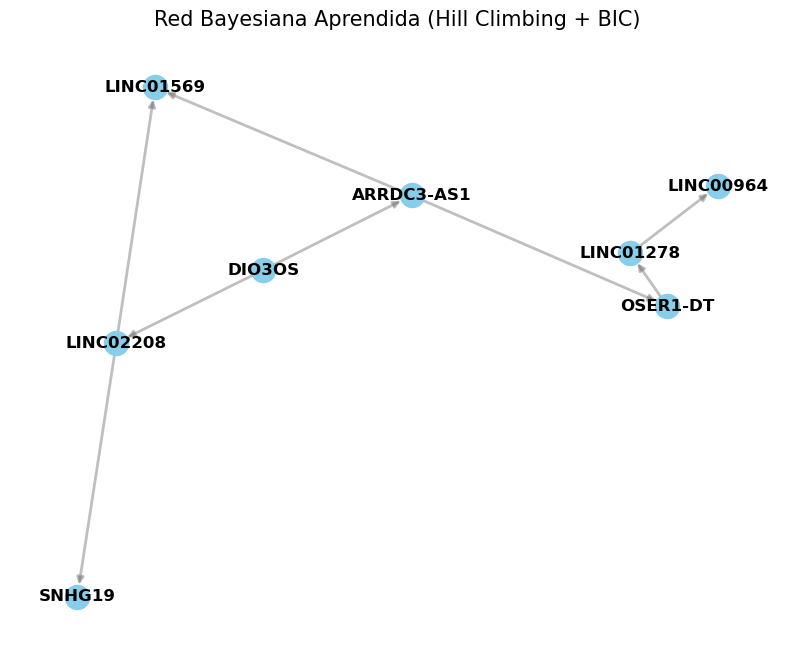

In [ ]:
labels = ['bajo', 'alto']
df_discretized = df_final.copy()
for col in df_final.columns:
    df_discretized[col] = pd.qcut(df_final[col], q=2, labels=labels, duplicates='drop')

data_encoded = pd.DataFrame()

for col in df_discretized.columns:
    dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
    dummies = dummies.drop(columns=[col + '_alto'], errors='ignore')  # 'errors="ignore"' maneja el caso de que no exista esa columna
    data_encoded = pd.concat([data_encoded, dummies], axis=1)
data_encoded = data_encoded.astype(int)
data_encoded.columns = data_encoded.columns.str.replace('_bajo', '', regex=False)

hc = HillClimbSearch(data_encoded)
best_model = hc.estimate(scoring_method='bic-d')

edges = best_model.edges()
G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(10, 8))  # Tamaño del gráfico
pos = nx.spring_layout(G)  # Layout de la red (puedes cambiar el tipo)
nx.draw_networkx_nodes(G, pos,  node_color="skyblue")  # Dibujar los nodos
nx.draw_networkx_edges(G, pos, width=2.0, alpha=0.5, edge_color="gray",arrows = True)  # Dibujar las aristas
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold", font_color="black")  # Etiquetas

# Mostrar el gráfico
plt.title("Red Bayesiana Aprendida (Hill Climbing + BIC)", size=15)
plt.axis('off')  # Quitar los ejes para mejor presentación
plt.show()

# Borrador

In [ ]:
# Separar variables y target
X = df2.drop(columns='Grupo_Tratamiento')
X = X[coef_df['Variable'].to_list()]  # Seleccionar solo las variables del dataframe de coeficientes
y = df2['Grupo_Tratamiento']

# Estandarizar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Estándariza X sin la constante

X_scaled = pd.DataFrame(X_scaled, columns=X.columns,index = y.index)


# Ajustar el modelo de regresión logística
model = sm.Logit(y, X_scaled)
result = model.fit()

# Mostrar un resumen con p-valores, coeficientes y pseudo R^2
print(result.summary())

# Obtener el pseudo R^2 de McFadden
pseudo_r2 = 1 - (result.llf / result.llnull)
print(f"Pseudo R^2: {pseudo_r2}")

In [ ]:
# Inicializar lista para guardar los resultados
resultados = []

# Número de iteraciones del bootstrap
n_iter = 10000
random_state = 42  # puedes quitar esto si quieres total aleatoriedad

np.random.seed(random_state)

X_total = df2.drop(columns='Grupo_Tratamiento')
y_total = df2['Grupo_Tratamiento']
variables_totales = X_total.columns.tolist()

for i in tqdm(range(n_iter)):
    # Selección aleatoria de variables
    n_vars = np.random.randint(5, len(variables_totales) + 1)
    vars_seleccionadas = np.random.choice(variables_totales, size=n_vars, replace=False)

    # Subset de datos
    X = X_total[vars_seleccionadas]
    y = y_total

    # Hacer bootstrap del conjunto de entrenamiento (con reemplazo)
    X_boot, y_boot = resample(X, y, replace=True, n_samples=len(X), random_state=None)

    # Out-of-bag samples (muestras que no están en el bootstrap)
    mask = ~X.index.isin(X_boot.index)
    X_oob = X.loc[mask]
    y_oob = y.loc[mask]

    # Escalar
    scaler = StandardScaler()
    X_boot_scaled = scaler.fit_transform(X_boot)
    X_oob_scaled = scaler.transform(X_oob) if not X_oob.empty else None

    # Hiperparámetro aleatorio
    c_value = 10 ** np.random.uniform(-2, 2)

    # Entrenar
    modelo = LogisticRegression(penalty='l1', solver='liblinear', C=c_value, max_iter=1000)
    modelo.fit(X_boot_scaled, y_boot)

    # Evaluar (solo si hay muestras OOB)
    if X_oob_scaled is not None and len(y_oob) > 0:
        y_pred_oob = modelo.predict(X_oob_scaled)
        y_pred_boot = modelo.predict(X_boot_scaled)
        r2 = r2_score(y_oob, y_pred_oob)
        acc_oob = accuracy_score(y_oob, y_pred_oob)
        acc_boot = accuracy_score(y_boot, y_pred_boot)
    else:
        r2 = np.nan
        acc_oob = np.nan
        acc_boot = accuracy_score(y_boot, modelo.predict(X_boot_scaled))

    # Guardar resultados
    for var, coef in zip(vars_seleccionadas, modelo.coef_[0]):
        resultados.append({
            'Iteración': i,
            'Variable': var,
            'Coeficiente': coef,
            'C': c_value,
            'R2': r2,
            'Accuracy_Test': acc_oob,
            'Accuracy_Train': acc_boot
        })

df_resultados = pd.DataFrame(resultados)

#df_resultados = df_resultados[df_resultados['Coeficiente'] != 0]
df_resultados_bootstrpaLogit = df_resultados.groupby('Variable').agg(
    Conteo=('Variable', 'count'),
    Promedio_Coeficiente=('Coeficiente', 'mean'),
    Promedio_Train_accuracy=('Accuracy_Train','mean'),
    Promedio_Test_accuracy=('Accuracy_Test','mean')
).reset_index()



# Ordenar por porcentaje y promedio de importancia

df_resultados_bootstrpaLogit['Importancia (abs)'] = np.abs(df_resultados_bootstrpaLogit['Promedio_Coeficiente'])
df_resultados_bootstrpaLogit = df_resultados_bootstrpaLogit.sort_values(by=['Importancia (abs)'], ascending=False).drop(columns='Importancia (abs)')
df_resultados_bootstrpaLogit

In [ ]:
#####CLUSTERING PARA SABER SI INDIVIDUOS DE CONTROL O TRATAMIENTO SE INCLUYEN EN UN MISMO CLUSTER

# Método del Codo
df_scaled1 = df_scaled.copy()
inertia = []
silhouette_scores = []
range_n_clusters = range(2, 11)  # Evaluamos entre 2 y 10 clusters

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(df_scaled1)
    
    # Guardamos la inercia para la técnica del codo
    inertia.append(kmeans.inertia_)
    
    # Calculamos el score de silueta para el método de silueta
    score = silhouette_score(df_scaled1, kmeans.labels_)
    silhouette_scores.append(score)

# Gráfico del Método del Codo
plt.figure(figsize=(14, 6))

# Subgráfico para la técnica del codo
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.grid(True)

# Subgráfico para el Método de la Silueta
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='--', color='r')
plt.title('Método de la Silueta')
plt.xlabel('Número de clusters')
plt.ylabel('Puntaje de Silueta')
plt.grid(True)

plt.tight_layout()
plt.show()

ncluster = 2
kmeans = KMeans(n_clusters=ncluster, random_state=42) #2 clusters, uno de control y otro de tratamiento
kmeans.fit(df_scaled1)
# Asignar cada variable a un cluster
clusters = kmeans.labels_
df_scaled1['cluster'] = clusters

for cluster in range(ncluster):
    df_scaled1Clust = df_scaled1[df_scaled1['cluster'] == cluster].reset_index()
    df_scaled1Clust['Grupo'] = np.where(df_scaled1Clust['index'].str.contains('A'), 'Tratamiento', 
              np.where(df_scaled1Clust['index'].str.contains('C'), 'Control', 'Otro'))
    conteo = df_scaled1Clust['Grupo'].value_counts()
    proporcion = df_scaled1Clust['Grupo'].value_counts(normalize=True) * 100
    print('CLUSTER',cluster)
    for categoria, (cantidad, prop) in zip(conteo.index, zip(conteo, proporcion)):
            print(f"{categoria}: {cantidad} ({prop:.2f}%)")

In [ ]:
############################################ OLS ############################
import statsmodels.api as sm

X = df_scaled2.drop(columns=["Grupo_Tratamiento"]) 
y = df_scaled2["Grupo_Tratamiento"]  

# Lista para almacenar los coeficientes y p-valores
coefficients_dict = {col: [] for col in X.columns}  
p_values_dict = {col: [] for col in X.columns}

# Número de iteraciones
n_iterations = 5000  # Puedes modificar el número de iteraciones

# Realizamos el loop para seleccionar 5 variables aleatorias y hacer la regresión
for _ in range(n_iterations):
    # Seleccionar aleatoriamente 5 variables
    selected_features = random.sample(list(X.columns), 5)
    X_selected = X[selected_features]
    
    # Añadir la constante (intercepto)
    X_selected_with_intercept = sm.add_constant(X_selected)
    
    # Ajustar el modelo de regresión lineal
    model = sm.OLS(y, X_selected_with_intercept)
    result = model.fit()
    
    for feature in selected_features:
        coefficients_dict[feature].append((float(result.params[feature])))
        p_values_dict[feature].append((float(result.pvalues[feature])))
        


mean_coefficients = {k: np.sum(v)/len(v) for k, v in coefficients_dict.items()}
mean_p_values = {k: np.sum(v)/len(v) for k, v in p_values_dict.items()}

results_df = pd.DataFrame({
    'Variable': list(mean_coefficients.keys()),
    'Coeficiente Promedio': list(mean_coefficients.values()),
    'P-Valor Promedio': list(mean_p_values.values())
})

results_df = results_df[results_df['P-Valor Promedio']<0.05]
mostImpFeaturesRegression = results_df.sort_values('Coeficiente Promedio', ascending = False)
mostImpFeaturesRegression

In [ ]:
########################################### LOGÍSTICA ###################################33
import warnings
warnings.filterwarnings("ignore")

X = df_scaled2.drop(columns=["cluster", "Grupo_Tratamiento"]) 
y = df_scaled2["Grupo_Tratamiento"]  

# Lista para almacenar los coeficientes y p-valores
coefficients_dict = {col: [] for col in X.columns}  
p_values_dict = {col: [] for col in X.columns}

# Número de iteraciones
n_iterations = 5000  # Puedes modificar el número de iteraciones

# Realizamos el loop para seleccionar 3 variables aleatorias y hacer la regresión logística
for _ in range(n_iterations):
    # Seleccionar aleatoriamente 3 variables
    selected_features = random.sample(list(X.columns), 1)
    X_selected = X[selected_features]
    
    # Añadir la constante (intercepto)
    X_selected_with_intercept = sm.add_constant(X_selected)
    
    try:
        model = sm.Logit(y, X_selected_with_intercept)
        result = model.fit(disp=0)  # Evita que se muestre el resultado durante el ajuste
        
        for feature in selected_features:
            coefficients_dict[feature].append(float(result.params[feature]))
            p_values_dict[feature].append(float(result.pvalues[feature]))
    except:
        # Si ocurre un error (como singularidad), simplemente continuar con la siguiente iteración
        continue
# Calcular las medias de los coeficientes y p-valores
mean_coefficients = {k: np.sum(v)/len(v) for k, v in coefficients_dict.items()}
mean_p_values = {k: np.sum(v)/len(v) for k, v in p_values_dict.items()}

# Crear DataFrame con los resultados
results_df_log = pd.DataFrame({
    'Variable': list(mean_coefficients.keys()),
    'Coeficiente Promedio': list(mean_coefficients.values()),
    'P-Valor Promedio': list(mean_p_values.values())
})

# Filtrar para obtener solo aquellas variables con p-valor menor que 0.05
#results_df = results_df[results_df['P-Valor Promedio'] < 0.05]

results_df_log_MasSignificativos = results_df_log[results_df_log['P-Valor Promedio'] < 0.05].sort_values('Coeficiente Promedio',ascending = False)
#results_df_log_MasSignificativos['CoeficienteInterpretacion'] = np.exp(results_df_log_MasSignificativos['Coeficiente Promedio'])
results_df_log_MasSignificativos = results_df_log_MasSignificativos
results_df_log_MasSignificativos

In [ ]:
########### COMPARACIÓN DE RESULTADOS


treelist = mostImpFeaturesTree['Feature'].to_list()
reglist = mostImpFeaturesRegression['Variable'].to_list()
loglists = results_df_log_MasSignificativos['Variable'].to_list()

all_items = set(treelist + reglist + loglists)
df_comparacion = pd.DataFrame({'variable': list(all_items)})
df_comparacion['Arbol'] = df_comparacion['variable'].isin(treelist).astype(int)
df_comparacion['OLS'] = df_comparacion['variable'].isin(reglist).astype(int)
df_comparacion['Logistic'] = df_comparacion['variable'].isin(loglists).astype(int)

df_comparacion['frecuencia_total'] = (
    df_comparacion['Arbol'] +
    df_comparacion['OLS'] +
    df_comparacion['Logistic']
)
df_comparacion = df_comparacion.sort_values(by='frecuencia_total', ascending=False)
df_comparacion[df_comparacion['frecuencia_total'] >= 2]